In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
a = pd.read_csv('data/charge_radii.csv')

In [3]:
a.rename(columns = {'z' : 'Z', 'n' : 'N'}, inplace = True)

## In this notebook we do not know yet how to add the csv radius file into selected_data.h5, so for now we are going to add it by hand

In [4]:
# This cell helps you to extract a dictionary that contains all the nuclei with BE and radius predictions of all the models we have
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}


filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [5]:
# We are going to define all the necessary functions that we can use to extract the data set that we want

## Necessary Functions

In [6]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [7]:
def filtered_NZ_extraction(filtered_NZ): #This function will extract isotopes that we want in our analysis

    #We start applying constraints to the above NZ array
    filtered_NZ_new = [] # Create a new list
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >= 8)) & ( (isotope[0]%2 == 0) & (isotope[1]%2 == 0) ):
            filtered_NZ_new.append(isotope) # Choose the isotope that satisfies the above condition
    filtered_NZ = np.array(filtered_NZ_new) # Turn this into an array
    return filtered_NZ

def unified_NZ(models_data_sets, models_selected, filtered_NZ):
    for model in models_selected: # Loop throught every model
        filtered_NZ_new = [] 
        for isotope in filtered_NZ:
            if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
                filtered_NZ_new.append(isotope) #Choose every isotope that does appears in the model we are considering
        filtered_NZ = np.array(filtered_NZ_new)# Update our list of filtered_NZ and loop through the remaining models.
    #A dataframe containing this NZ inputs
    filtered_NZ_df = {'N' : filtered_NZ.T[0], 'Z': filtered_NZ.T[1]}
    filtered_NZ_df = pd.DataFrame(filtered_NZ_df)

    return filtered_NZ, filtered_NZ_df

def selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, heterogeneous_data_type, num_properties):
    selected_models_data_sets_list = []
    for i in range(num_properties):
        selected_models_data_sets=pd.DataFrame(filtered_NZ_df)

        for model in models_selected:
            a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'inner', on  = ['N', 'Z'])
            selected_models_data_sets[model] = a[heterogeneous_data_type[i]]
        # selected_models_data_sets.rename(columns={models_selected[0]: 'truth'}, inplace=True)
        selected_models_data_sets_list.append(selected_models_data_sets)
    return selected_models_data_sets_list

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets.copy() #This gives the initial values for models output
    
    # We will add a column of mass number and rearrange our dataframe
    models_output["A"] = models_output["N"] + models_output["Z"] 
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2]
    models_output = models_output[cols]

    #Next steps is to extract this dataframe at train,validation,test coordinates
    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]

    return [models_output,models_output_train,models_output_validation,models_output_test]

def filtered_models_output(Selected_element, models_output, train_coordinates, validation_coordinates, test_coordinates): 
    Z_range=(Selected_element,Selected_element)
    N_range=(0,300)

    
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output.iloc[train_coordinates][(models_output.iloc[train_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[train_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[train_coordinates]['N'] >= N_range[0]) & (models_output.iloc[train_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output.iloc[validation_coordinates][(models_output.iloc[validation_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[validation_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[validation_coordinates]['N'] >= N_range[0]) & (models_output.iloc[validation_coordinates]['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output.iloc[test_coordinates][(models_output.iloc[test_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[test_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[test_coordinates]['N'] >= N_range[0]) & (models_output.iloc[test_coordinates]['N'] <= N_range[1])]
    
    
    stable_selected_isotope=[]
    
    for i in range(len(stable_coordinates)):
        if stable_coordinates[i][1]==Selected_element:
            stable_selected_isotope.append(stable_coordinates[i])
    
    stable_selected_isotope=np.array(stable_selected_isotope)
    
    # df[df['Column1'].isin(values_array)]
    
    filtered_models_output_stable = models_output.iloc[train_coordinates][(models_output.iloc[train_coordinates]['Z'] >= Z_range[0]) & (models_output.iloc[train_coordinates]['Z'] <= Z_range[1]) & 
                         (models_output.iloc[train_coordinates]['N'].isin(stable_selected_isotope.T[0]))]
    
    return [filtered_models_output,filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test, filtered_models_output_stable]

def models_PC_output(Vt_hat, model_predictions, predictions_mean):
    models_PC = {}

    models_PC["PC_0"] = predictions_mean
    
    for i in range(components_kept):
        models_PC["PC_" + str(i+1)] = np.dot(Vt_hat[i], model_predictions.T)
    
    # models_PC["N"] = models_output["N"]
    # models_PC["Z"] = models_output["Z"]
    # models_PC["A"] = models_PC["N"] + models_PC["Z"]
    
    models_PC = pd.DataFrame(models_PC)

    return models_PC

def rndm_m_mass_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_mass = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_mass= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * samples[i][-2]**2 ) )))  
        
    lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
    median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
    upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

    return [lower_mass, median_mass, upper_mass]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

def rndm_m_mass_calculator_coverage(sigma, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * sigma**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def rndm_m_radius_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-1]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m
    

def coverage_calculation(rndm_m_full, models_output):
    percentiles = np.arange(0, 101, 5)


    data_total=len(rndm_m_full.T)
    data_true=models_output["truth"].tolist()
    M_evals=len(rndm_m_full)
    
    
    coverage = []
    
    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m_full.T[i])
            
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1  # Adjusted to avoid out-of-bounds
            
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
                
        # Calculate and store the coverage percentage
        coverage.append(count_covered / data_total * 100)
        
    return coverage
    

In [8]:
def plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint, title):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    lower, median, upper = supermodel_predictions_range

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    
    plt.plot(filtered_models_output["N"], -median/filtered_models_output['A'], color="darkkhaki", label=f'$f^\dagger$({Constraint})',linewidth=3)
    
    plt.plot(filtered_models_output["N"], -lower/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    plt.plot(filtered_models_output["N"], -upper/filtered_models_output['A'], color="darkkhaki",linestyle="dashed",linewidth=2,alpha=0.5)
    
    plt.fill_between(filtered_models_output["N"], -lower/filtered_models_output['A'], -upper/filtered_models_output['A'], color="darkkhaki",alpha=0.3)
    
    color_local= "khaki"
    
    
    # plt.plot(filtered_models_output["N"], -median_simplex_local/filtered_models_output['A'], color='purple', label='$f^\dagger$(Simplex Local)',linewidth=3)
    
    # # plt.plot(filtered_models_output["N"], lower, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    # # plt.plot(filtered_models_output["N"], upper, color=color_simplex,linestyle="dashed",linewidth=3,alpha=0.8)
    
    
    # plt.plot(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    # plt.plot(filtered_models_output["N"], -upper_simplex_local/filtered_models_output['A'], color="purple",linestyle="dashed",linewidth=2,alpha=0.8)
    
    # plt.fill_between(filtered_models_output["N"], -lower_simplex_local/filtered_models_output['A'], -upper_simplex_local/filtered_models_output['A'], color='purple',alpha=0.3)
    
    ax.scatter(x = filtered_models_output_train["N"], y = -filtered_models_output_train['truth']/filtered_models_output_train["A"], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    
    ax.scatter(x = filtered_models_output_validation["N"], y = -filtered_models_output_validation['truth']/filtered_models_output_validation["A"], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)

    ax.scatter(x = filtered_models_output_test["N"], y = -filtered_models_output_test['truth']/filtered_models_output_test["A"], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y =- filtered_models_output_stable['truth']/filtered_models_output_stable["A"], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    
    
    
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {Z}) $ {{\\cal {property}}}/A$ [{unit}]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
     
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)

    plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    plt.show()

In [9]:
def plot_model_predictions(filtered_models_output_list, models_selected, Selected_element_name):
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)

    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

    filtered_models_output= filtered_models_output_list[0]
    filtered_models_output_train= filtered_models_output_list[1]
    filtered_models_output_validation= filtered_models_output_list[2]
    filtered_models_output_test = filtered_models_output_list[3]
    filtered_models_output_stable = filtered_models_output_list[4]
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    i = 0
    for model in models_selected:
        plt.plot(filtered_models_output['N'], filtered_models_output[model],label = model, color=colors[i], alpha = 0.9,linewidth=5, zorder = 1)
        i+=1
    ax.scatter(x = filtered_models_output_train["N"], y = filtered_models_output_train['truth'], label = "Truth-Train",  alpha = 1,color=color_train,s=200,marker=marker_train,zorder=2)

    ax.scatter(x = filtered_models_output_validation["N"], y = filtered_models_output_validation['truth'], label = "Truth-Validation", alpha = 1,color=color_validation,s=350,marker=marker_validation,zorder=2)
    
    ax.scatter(x = filtered_models_output_test["N"], y = filtered_models_output_test['truth'], label = "Truth-Test", alpha = 1,color=color_test,s=350,marker=marker_test,zorder=2)
    
    ax.scatter(x = filtered_models_output_stable["N"], y = filtered_models_output_stable['truth'], label = "Truth-Stable", alpha = 1,color='k',s=80,marker="s",zorder=2)
    
    
    
    plt.xlabel("N",fontsize=35)
    plt.ylabel(Selected_element_name+" R(fm)",fontsize=35)
    # plt.legend(fontsize=18,markerscale=1 )
    plt.legend(fontsize=15,markerscale=1,ncol=2  )
    # plt.savefig(f'{savefig}')
    plt.show()

In [10]:
# Let'steal this from Pablo like we always do
def plot_heatmap(xvals, yvals, zvals, quantity_of_interest, model):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 




    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    # plt.savefig(f'{savefig}')
    plt.show()

def plot_heatmap_3D(xvals, yvals, zvals, title, elev=30, azim=-60):
    # Create figure and 3D axes
    fig, ax_3d = plt.subplots(figsize=(4, 3), dpi=200, subplot_kw={'projection': '3d'})
    
    # Normalize z values
    # z_normalized = (zvals - zvals.min()) / (zvals.max() - zvals.min())
    z_normalized = zvals
    # Define the size of the bars
    dx = dy = 1.5  # Width of the bars in the x and y directions
    dz = z_normalized  # Height of the bars (z values)

    # Create 3D bar plot
    ax_3d.bar3d(xvals, yvals, np.zeros_like(z_normalized), dx, dy, dz, color=plt.cm.plasma((zvals - zvals.min()) / (zvals.max() - zvals.min())))
    ax_3d.set_zlim(np.minimum(0, zvals.min()), zvals.max())
    # Set view angle
    ax_3d.view_init(elev=elev, azim=azim) 
    
    ax_3d.tick_params(axis='both', labelsize=8)  # Smaller font size for major ticks
    ax_3d.tick_params(axis='z', labelsize=8)
    
    # Set labels and title
    ax_3d.set_xlabel('Neutrons', fontsize = 5)
    ax_3d.set_ylabel('Protons', fontsize = 5)
    ax_3d.set_zlabel('Scaled Z', fontsize = 5)
    ax_3d.set_title(title)

    # Create a colorbar based on the plasma colormap and the normalization
    mappable = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=zvals.min(), vmax=zvals.max()))
    mappable.set_array(zvals)
    
    # Add the colorbar to the plot
    cbar = plt.colorbar(mappable, ax=ax_3d, shrink=0.5, aspect=10, location='right', pad=0.2)
    cbar.set_label(title, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    # Show plot
    plt.show()

In [11]:
# Let'steal this from Pablo like we always do
def plot_heatmap_savefig(xvals, yvals, zvals, quantity_of_interest, model, savefig):
    # Create scatter plot
    plt.rc("xtick", labelsize=10)
    plt.rc("ytick", labelsize=10)
    fig, ax = plt.subplots(figsize = (4,3), dpi = 200)
    
    sc = ax.scatter(xvals, yvals, c=zvals, s=0.5, cmap='plasma', marker = 's')
    # plt.colorbar(sc, label='Z-Value')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label(f'{quantity_of_interest}', fontsize=10) 
    cbar.ax.tick_params(labelsize=10) 




    plt.xlabel('Neutrons',fontsize=10)
    plt.ylabel('Protons',fontsize=10)

    ax.grid(True)
    ax.axis('equal')
    plt.title(f'{model}')
    plt.tight_layout()
    plt.savefig(f'{savefig}')
    plt.show()

In [12]:
def supermodel_residuals_radius_calculator(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_radius_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_radius_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    # real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_radius_train['truth'])-predictions_mean_radius_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_radius_train.T)
    supermodel_validation = model_weights.dot(model_predictions_radius_validation.T)
    supermodel_test = model_weights.dot(model_predictions_radius_test.T)
    supermodel_full = model_weights.dot(model_predictions_radius.T)
    
    supermodel_residuals_train=supermodel_train-models_output_radius_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_radius_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_radius_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_radius['truth'].tolist()

    return supermodel_residuals_full

In [13]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full) # Make sure that nuclei we analyze have proton and neutron number of 8 or above

In [14]:
filtered_NZ= filtered_NZ_extraction(filtered_NZ) #Extract even even nuclei with N, Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ(models_data_sets, models_selected, filtered_NZ) #Choose nuclei that appears in every models of interest

In [15]:
# Extracting 2 data frames that contains predictions of different properties of nuclei
selected_models_data_sets_mass, selected_models_data_sets_radius = selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, \
                                                                                                        heterogeneous_data_type, num_properties)

selected_models_data_sets_radius = pd.merge(selected_models_data_sets_radius, a[['N', 'Z', 'radius_val']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_radius.rename(columns = {'radius_val' : 'truth'}, inplace = True)
cols_radius = list(selected_models_data_sets_radius.keys())
# The next 2 lines help you to transition the truth column to the start of the dataframe
cols_radius.remove('truth')
cols_radius.insert(2, 'truth')
selected_models_data_sets_radius = selected_models_data_sets_radius[cols_radius]
# This dataframe will contains all the experimental data and predictions of models for radius


truth_BE = pd.read_hdf("./data./selected_data.h5", key = 'AME2020')
truth_BE_df = pd.DataFrame(truth_BE)
selected_models_data_sets_mass = pd.merge(selected_models_data_sets_mass, truth_BE_df[['N', 'Z', 'BE']], how = 'inner', on = ['N', 'Z'])
selected_models_data_sets_mass.rename(columns = {'BE' : 'truth'}, inplace = True)
cols_mass = list(selected_models_data_sets_mass.keys())
# The next 2 lines help you to trainsition the truth column to the start of the dataframe
print(cols_mass)
cols_mass.remove('truth')
cols_mass.insert(2, 'truth')
selected_models_data_sets_mass = selected_models_data_sets_mass[cols_mass]
# This dataframe will contains all the experimental data and predictions of models for binding energies

['N', 'Z', 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1', 'truth']


In [16]:
selected_models_data_sets_radius['truth'].isnull().sum()

4

In [17]:
selected_models_data_sets_radius = selected_models_data_sets_radius.copy().dropna().reset_index(drop = True)

### Now we have 2 data sets separately for mass and radius, let's execute the usual analysis that we already did

In [18]:
filtered_NZ_df_radius = selected_models_data_sets_radius[['N', 'Z']]
filtered_NZ_radius = np.array(filtered_NZ_df_radius)
Full_set_radius = filtered_NZ_radius.copy()

In [19]:
filtered_NZ_df_mass = selected_models_data_sets_mass[['N', 'Z']]
filtered_NZ_mass = np.array(filtered_NZ_df_mass)
Full_set_mass = filtered_NZ_mass.copy()

### We will now want to seperate these filtered nuclei into different regions

In [20]:
stable_coordinates_df = pd.DataFrame({'N' : stable_coordinates.T[0], 'Z' : stable_coordinates.T[1]})
stable_coordinates_radius_df = pd.merge(filtered_NZ_df_radius, stable_coordinates_df, how = 'inner')
stable_coordinates_radius = stable_coordinates_radius_df.values

In [21]:
stable_coordinates.shape

(167, 2)

In [22]:
#Traditional way with stable coordinates to seperate our data points for nuclei - radius data sets

distance1=1.75
distance2=2.5

training_set_radius, validation_set_radius, test_set_radius, train_coordinates_radius, validation_coordinates_radius,test_coordinates_radius=separate_points_distance_allSets(filtered_NZ_radius, stable_coordinates, distance1,distance2)

In [23]:
train_coordinates_radius.shape

(167,)

In [24]:
#Traditional way with stable coordinates to seperate our data points for nuclei - mass data sets

distance1=2
distance2=3

training_set_mass, validation_set_mass, test_set_mass, train_coordinates_mass, validation_coordinates_mass,test_coordinates_mass=separate_points_distance_allSets(filtered_NZ_mass, stable_coordinates, distance1,distance2)

### We will graph the nuclei that we separate to 3 regions

In [25]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(12,10), dpi=100)

plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4



ax.scatter(x = training_set_mass.T[0], y = training_set_mass.T[1], label = "Train ("+ str(len(training_set_mass))+")", alpha = alpha_train,color=color_train,s=size_train,marker=marker_train)

ax.scatter(x = validation_set_mass.T[0], y = validation_set_mass.T[1], label = "Valid. (" + str(len(validation_set_mass))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)

ax.scatter(x = test_set_mass.T[0], y = test_set_mass.T[1], label = "Test (" + str(len(test_set_mass))+")", alpha = alpha_test,color=color_test,s=size_test,marker=marker_test)


ax.scatter(x = stable_coordinates.T[0], y = stable_coordinates.T[1], label = "Stable", alpha = 0.8,color='black',s=11,marker="s")





# ax.scatter(x = np.array(AME2020New).T[0], y = np.array(AME2020New).T[1], label = "Valid. (" + str(len(validation_set))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)


plt.xlabel('')

plt.annotate('Neutrons', xy=(0.35, 0.1), xycoords='axes fraction',
             ha='center', va='top', fontsize=45) 
plt.ylabel('')

plt.annotate('Protons', xy=(0.05,0.7), xycoords='axes fraction',
             ha='center', va='top', fontsize=45,rotation =90) 


# plt.ylabel("Protons",fontsize=45)
plt.legend(fontsize=34,markerscale=3 ,loc =(0.53,0.03))
plt.show()

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1200x1000 with 1 Axes>

In [25]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(12,10), dpi=100)

plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_train='s'
marker_validation='*'
marker_test='o'



size_train=30
size_validation=80
size_test=35

alpha_train=0.8
alpha_validation=0.9
alpha_test=0.4



ax.scatter(x = training_set_radius.T[0], y = training_set_radius.T[1], label = "Train ("+ str(len(training_set_radius))+")", alpha = alpha_train,color=color_train,s=size_train,marker=marker_train)

ax.scatter(x = validation_set_radius.T[0], y = validation_set_radius.T[1], label = "Valid. (" + str(len(validation_set_radius))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)

ax.scatter(x = test_set_radius.T[0], y = test_set_radius.T[1], label = "Test (" + str(len(test_set_radius))+")", alpha = alpha_test,color=color_test,s=size_test,marker=marker_test)


ax.scatter(x = stable_coordinates.T[0], y = stable_coordinates.T[1], label = "Stable", alpha = 0.8,color='black',s=11,marker="s")





# ax.scatter(x = np.array(AME2020New).T[0], y = np.array(AME2020New).T[1], label = "Valid. (" + str(len(validation_set))+")", alpha = alpha_validation,color=color_validation,s=size_validation,marker=marker_validation)


plt.xlabel('')

plt.annotate('Neutrons', xy=(0.35, 0.1), xycoords='axes fraction',
             ha='center', va='top', fontsize=45) 
plt.ylabel('')

plt.annotate('Protons', xy=(0.05,0.7), xycoords='axes fraction',
             ha='center', va='top', fontsize=45,rotation =90) 


# plt.ylabel("Protons",fontsize=45)
plt.legend(fontsize=34,markerscale=3 ,loc =(0.53,0.03))
# plt.savefig('Plots/Radii data/Nuclei with real CR.png')
plt.show()

RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 1200x1000 with 1 Axes>

In [ ]:
# After having separated our data points into intrapolation and extrapolation part, first we have to extract all the model predictions and perform
# PCA on that data set

In [28]:
#Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [29]:
#Separate them for further use
[models_output_mass, models_output_mass_train, models_output_mass_validation, models_output_mass_test] = models_output_mass_list
[models_output_radius, models_output_radius_train, models_output_radius_validation, models_output_radius_test] = models_output_radius_list

In [30]:
filtered_models_output_mass_list_50 = filtered_models_output(50, models_output_mass, train_coordinates_mass, validation_coordinates_mass, test_coordinates_mass)
filtered_models_output_radius_list_20 = filtered_models_output(20, models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [31]:
filtered_models_output_mass_50 = filtered_models_output_mass_list_50[0]
filtered_models_output_mass_train_50 = filtered_models_output_mass_list_50[1]
filtered_models_output_mass_validation_50 = filtered_models_output_mass_list_50[2]
filtered_models_output_mass_test_50 = filtered_models_output_mass_list_50[3]
filtered_models_output_mass_stable_50 = filtered_models_output_mass_list_50[4]

filtered_models_output_radius_20 = filtered_models_output_radius_list_20[0]
filtered_models_output_radius_train_20 = filtered_models_output_radius_list_20[1]
filtered_models_output_radius_validation_20 = filtered_models_output_radius_list_20[2]
filtered_models_output_radius_test_20 = filtered_models_output_radius_list_20[3]
filtered_models_output_radius_stable_20 = filtered_models_output_radius_list_20[4]

model_predictions_mass=models_output_mass[key_list].values
model_predictions_mass_train=models_output_mass_train[key_list].values
model_predictions_mass_validation=models_output_mass_validation[key_list].values
model_predictions_mass_test=models_output_mass_test[key_list].values

model_predictions_radius=models_output_radius[key_list].values
model_predictions_radius_train=models_output_radius_train[key_list].values
model_predictions_radius_validation=models_output_radius_validation[key_list].values
model_predictions_radius_test=models_output_radius_test[key_list].values

model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))

predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

predictions_mean_radius_df = pd.DataFrame({'N' : filtered_NZ_radius.T[0], 'Z' : filtered_NZ_radius.T[1], 'PC_0' : predictions_mean_radius})
filtered_predictions_mean_radius_list_20 = filtered_models_output(20, predictions_mean_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)

In [32]:
filtered_predictions_mean_radius_list_20[0]

,N,Z,PC_0
23,20,20,3.485110
24,22,20,3.489794
25,24,20,3.495704
26,26,20,3.503571
27,28,20,3.512824
28,30,20,3.532097


### Let's now find the parameters using all models space by OLS

In [33]:
XTX_rad = model_predictions_radius.T.dot(model_predictions_radius)
XTX_rad_inv = np.linalg.inv(XTX_rad)
super_params = XTX_rad_inv.dot(model_predictions_radius.T).dot(models_output_radius['truth'])

In [34]:
#After we have found the OLS solution to our parameters, let's compare it with the PCA solution that w e will analyse below

In [35]:
models_output_radius[models_selected]

,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
0,2.729,2.691,2.747,2.735,2.794203,2.824011,2.795792,2.817382,2.793546,2.790816
1,2.733,2.704,2.749,2.728,2.793734,2.825080,2.799074,2.807857,2.785015,2.781329
2,2.956,2.912,2.945,2.955,2.956188,2.987489,2.964309,2.991813,2.966094,2.973445
3,2.986,2.942,2.975,2.973,2.942506,2.973045,2.951974,2.974810,2.935663,2.967315
4,2.960,2.949,2.978,2.941,2.964141,2.972133,2.976913,2.981346,2.925008,2.968485
...,...,...,...,...,...,...,...,...,...,...
340,5.933,5.920,5.930,5.942,5.910061,5.918577,5.915247,5.902641,5.908618,5.923415
341,5.935,5.921,5.933,5.936,5.919476,5.928108,5.924384,5.908823,5.911968,5.928126
342,5.948,5.938,5.947,5.951,5.929864,5.939063,5.934703,5.920200,5.923912,5.940104
343,5.958,5.945,5.956,5.964,5.939141,5.949234,5.944656,5.930929,5.935161,5.951470


In [36]:
centering_data = True

if centering_data:
    model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,None]
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train.reshape(167,1)
    # model_predictions_mass_train_processed = model_predictions_mass_train - predictions_mean_mass_train[:,np.newaxis]

if centering_data:
    model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,None]
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train.reshape(167,1)
    # model_predictions_radius_train_processed = model_predictions_radius_train - predictions_mean_radius_train[:,np.newaxis]

if centering_data:
    model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(334,1)
    # model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

In [37]:
if centering_data:
    model_predictions_radius_validation_processed = model_predictions_radius_validation - predictions_mean_radius_validation[:,None]
    model_predictions_radius_test_processed = model_predictions_radius_test - predictions_mean_radius_test[:,None]
    model_predictions_radius_processed = model_predictions_radius - predictions_mean_radius[:,None]

### Some of the few cells below will help us visualize if our data is correlated or not

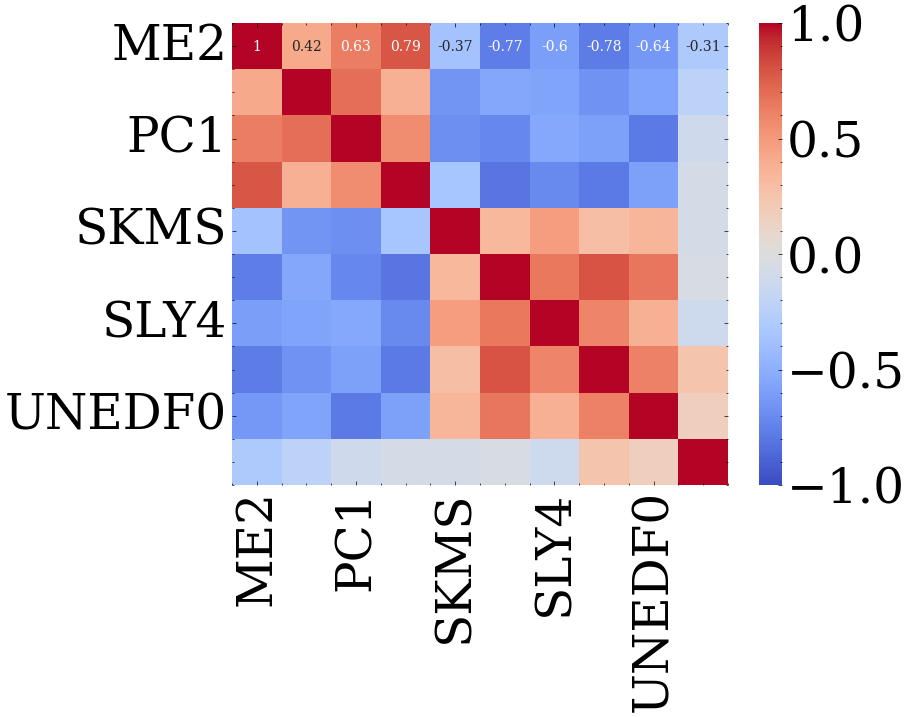

In [38]:
plt.figure(figsize = (8,6))

Pearson_corr_matrix = (models_output_radius_train[models_selected] - predictions_mean_radius_train[:, None]).corr(method='pearson')
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
sns.heatmap(Pearson_corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.savefig('Plots/Radii data/Pearson corr matrix comparison/Pearson matrix - radii data')
plt.show()


In [39]:
Pearson_corr_matrix

,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1
ME2,1.000000,0.420497,0.631367,0.787470,-0.373611,-0.768636,-0.600825,-0.775788,-0.636512,-0.307899
MEdelta,0.420497,1.000000,0.694151,0.378744,-0.649129,-0.551718,-0.566813,-0.657295,-0.566042,-0.220107
PC1,0.631367,0.694151,1.000000,0.558109,-0.684902,-0.720559,-0.541741,-0.589943,-0.786340,-0.104929
NL3S,0.787470,0.378744,0.558109,1.000000,-0.349802,-0.806930,-0.708099,-0.787330,-0.593721,-0.063593
SKMS,-0.373611,-0.649129,-0.684902,-0.349802,1.000000,0.332430,0.481236,0.290000,0.351479,-0.074315
SKP,-0.768636,-0.551718,-0.720559,-0.806930,0.332430,1.000000,0.654296,0.794796,0.659244,-0.046654
SLY4,-0.600825,-0.566813,-0.541741,-0.708099,0.481236,0.654296,1.000000,0.596230,0.380453,-0.110514
SV,-0.775788,-0.657295,-0.589943,-0.787330,0.290000,0.794796,0.596230,1.000000,0.616422,0.251165
UNEDF0,-0.636512,-0.566042,-0.786340,-0.593721,0.351479,0.659244,0.380453,0.616422,1.000000,0.169749
UNEDF1,-0.307899,-0.220107,-0.104929,-0.063593,-0.074315,-0.046654,-0.110514,0.251165,0.169749,1.000000


In [40]:
def pca_singular_values(X):
    # Step 1: Center the data
    X_centered = X - np.mean(X, axis=1)[:, np.newaxis]
    # Step 2: Compute the covariance matrix
    cov_matrix = np.cov(X_centered, rowvar=False)  # rowvar=False because columns are features

    # Step 3: Perform eigenvalue decomposition
    eigenvalues, _ = np.linalg.eigh(cov_matrix)

    # Step 4: Compute singular values
    # Eigenvalues are sorted in ascending order, so we reverse them to get the singular values
    singular_values = np.sqrt(np.flip(eigenvalues))

    return singular_values
pca_singular_values(model_predictions_radius_train)

array([3.12273286e-02, 1.58994779e-02, 1.10347793e-02, 9.04324978e-03,
       8.37674927e-03, 5.83882705e-03, 5.01284632e-03, 4.43743068e-03,
       3.43008749e-03, 2.12027224e-10])

In [41]:
covariance_matrix =  model_predictions_radius_train_processed.T.dot(model_predictions_radius_train_processed)
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
np.flip(np.sqrt(eigenvalues))

C:\Users\congn\AppData\Local\Temp\ipykernel_28980\3887124558.py:3: RuntimeWarning: invalid value encountered in sqrt
  np.flip(np.sqrt(eigenvalues))


array([0.52125392, 0.26938716, 0.20483294, 0.13936181, 0.1104372 ,
       0.09051003, 0.07201374, 0.06285643, 0.04859427,        nan])

In [42]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(model_predictions_radius_train_processed.T)
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[6.20984577e-01 1.65857819e-01 9.58918574e-02 4.43884209e-02
 2.78748733e-02 1.87230039e-02 1.18525800e-02 9.02987097e-03
 5.39699755e-03 4.07589309e-32]


In [43]:
pca.singular_values_

array([5.21253916e-01, 2.69387165e-01, 2.04832936e-01, 1.39361808e-01,
       1.10437197e-01, 9.05100255e-02, 7.20137408e-02, 6.28564278e-02,
       4.85942669e-02, 1.33542750e-16])

[5.21253916e-01 2.69387165e-01 2.04832936e-01 1.39361808e-01
 1.10437197e-01 9.05100255e-02 7.20137408e-02 6.28564278e-02
 4.85942669e-02 2.09027186e-14]


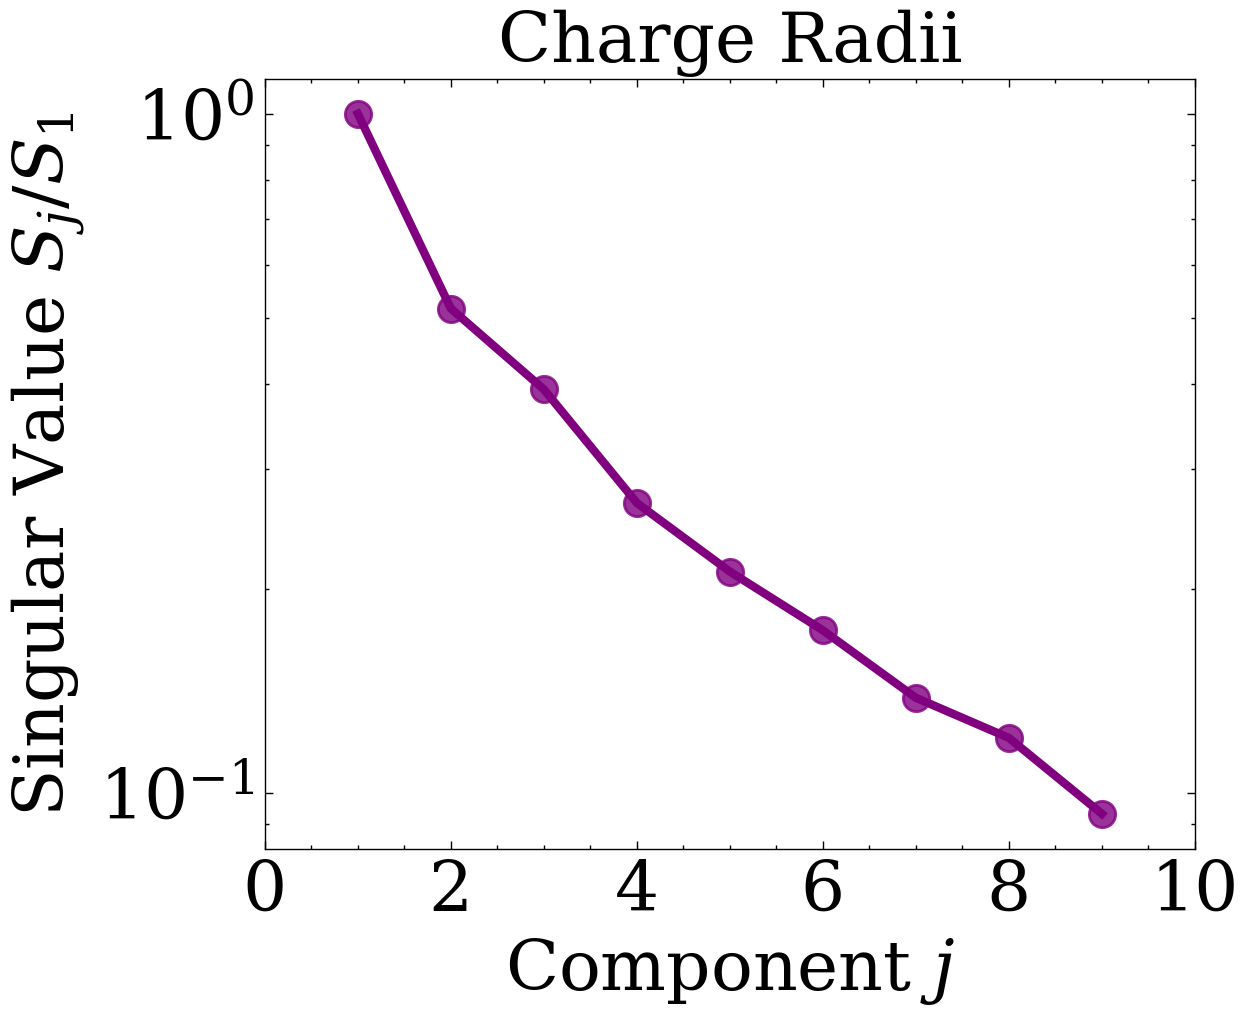

In [44]:
U, S, Vt = np.linalg.svd(model_predictions_radius_train_processed)

print(S)

plt.rc("xtick", labelsize = 25)
plt.rc("ytick", labelsize = 25)
plt.rcParams['text.usetex'] = False
fig, ax = plt.subplots(figsize = (6,5), dpi = 200)

ax.scatter(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", alpha = 0.8, s = 90, marker = 'o')
ax.plot(np.arange(1, S.size ), S[:-1]/S[0], color = "purple", linewidth = 3)

ax.set_xticks([0,2,4,6,8,10])
plt.xlabel("Component $j$", fontsize = 25)
plt.ylabel("Singular Value $S_j/S_1$", fontsize = 25)
plt.yscale("log")
plt.title('Charge Radii', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Singular Values/Singular Values - Radius Calibration.png')
plt.show()

In [45]:
components_kept = 9
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [46]:
models_PC_radius = models_PC_output(Vt_hat, model_predictions_radius, predictions_mean_radius)
models_PC_radius_train = models_PC_output(Vt_hat, model_predictions_radius_train, predictions_mean_radius_train)
models_PC_radius_validation = models_PC_output(Vt_hat, model_predictions_radius_validation, predictions_mean_radius_validation)
models_PC_radius_test = models_PC_output(Vt_hat, model_predictions_radius_test, predictions_mean_radius_test)

In [47]:
models_PC_radius_test

,PC_0,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9
0,2.951302,-0.142092,-0.043969,0.158802,-0.076893,0.047535,0.053009,-0.012248,0.099099,-0.186586
1,2.988196,-0.139232,-0.045080,0.051100,0.046297,0.002512,0.077167,-0.054720,0.094917,-0.028862
2,3.390650,-0.099125,-0.083785,0.034009,0.102338,0.009764,-0.016109,-0.023745,0.169360,-0.135946
3,4.163620,-0.016856,0.152076,-0.280786,-0.425844,0.156064,0.155862,0.323874,0.252510,0.186391
4,4.150429,-0.121901,0.011213,-0.341533,-0.412187,0.193687,0.075760,0.245675,0.174459,0.042437
...,...,...,...,...,...,...,...,...,...,...
104,5.920356,0.036097,0.086690,-0.053498,0.085818,-0.033338,-0.121242,0.048564,0.011153,0.059839
105,5.924588,0.011766,0.084023,-0.041073,0.062693,-0.003693,-0.092881,0.014344,0.041039,0.048468
106,5.937185,0.022922,0.089622,-0.032016,0.058250,-0.008706,-0.102797,0.029394,0.043080,0.056088
107,5.947359,0.022408,0.083425,-0.044608,0.080397,-0.017455,-0.117538,0.038571,0.027378,0.051652


### Let's take a quick look at how many PCs do we need to use

In [50]:
def PC_RMSE_calculator_mass(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_radius_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_radius_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    # real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_radius_train['truth'])-predictions_mean_radius_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_mass_train.T)
    supermodel_validation = model_weights.dot(model_predictions_mass_validation.T)
    supermodel_test = model_weights.dot(model_predictions_mass_test.T)
    supermodel_full = model_weights.dot(model_predictions_mass.T)
    
    supermodel_residuals_train=supermodel_train-models_output_mass_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_mass_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_mass_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_mass['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [51]:
def PC_RMSE_calculator_radius(components_kept):
    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i] for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)]) 

    if centering_data:
        num_components = components_kept + 1
    else:
        num_components = components_kept
    
    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_radius_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_radius_train.T)
    # models_PC_train["N"] = models_output_train["N"]
    # models_PC_train["Z"] = models_output_train["Z"]
    # models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################
    key_list_PCs=list(models_PC_train.keys())

    # real_data = list(models_output_mass_train['truth']) + list(models_output_radius_train['truth'])
    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_radius_train['truth'])-predictions_mean_radius_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    
    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)

    #After finding the least squared solution, we will find the corresponding weights
    model_weights = np.dot(beta, Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0]))
    model_weights = np.array(model_weights)

    #We can create super models based on their corresponding weights
    supermodel_train = model_weights.dot(model_predictions_radius_train.T)
    supermodel_validation = model_weights.dot(model_predictions_radius_validation.T)
    supermodel_test = model_weights.dot(model_predictions_radius_test.T)
    supermodel_full = model_weights.dot(model_predictions_radius.T)
    
    supermodel_residuals_train=supermodel_train-models_output_radius_train['truth'].tolist()
    supermodel_residuals_validation= supermodel_validation-models_output_radius_validation['truth'].tolist()
    supermodel_residuals_test = supermodel_test-models_output_radius_test['truth'].tolist()
    supermodel_residuals_full = supermodel_full-models_output_radius['truth'].tolist()

    sigma_train=np.sqrt(np.sum(supermodel_residuals_train**2) / len(supermodel_residuals_train) )
    sigma_validation=np.sqrt(np.sum(supermodel_residuals_validation**2) / len(supermodel_residuals_validation) )
    sigma_test=np.sqrt(np.sum(supermodel_residuals_test**2) / len(supermodel_residuals_test) )
    sigma_full=np.sqrt(np.sum(supermodel_residuals_full**2) / len(supermodel_residuals_full) )

    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [52]:
centering_data = True
if centering_data:
    s_mass_validation=[np.linalg.norm(np.array(models_output_mass_validation["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
    s_mass_test=[np.linalg.norm(np.array(models_output_mass_test["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
    s_mass_train=[np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
    s_mass_all=[np.linalg.norm(np.array(models_output_mass["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator_mass(i)
        s_mass_train.append(res[0])
        s_mass_validation.append(res[1])
        s_mass_test.append(res[2])
        
        s_mass_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

In [53]:
centering_data = True
if centering_data:
    s_radius_validation=[np.linalg.norm(np.array(models_output_radius_validation["truth"].tolist())-predictions_mean_radius_validation)/np.sqrt(len(predictions_mean_radius_validation))]
    s_radius_test=[np.linalg.norm(np.array(models_output_radius_test["truth"].tolist())-predictions_mean_radius_test)/np.sqrt(len(predictions_mean_radius_test))]
    s_radius_train=[np.linalg.norm(np.array(models_output_radius_train["truth"].tolist())-predictions_mean_radius_train)/np.sqrt(len(predictions_mean_radius_train))]
    s_radius_all=[np.linalg.norm(np.array(models_output_radius["truth"].tolist())-predictions_mean_radius)/np.sqrt(len(predictions_mean_radius))]
    
else:
    s_test=[]
    s_train=[]
    s_validation=[]
    s_all=[]

if centering_data:
    for i in range(1,len(S)):
        res=PC_RMSE_calculator_radius(i)
        s_radius_train.append(res[0])
        s_radius_validation.append(res[1])
        s_radius_test.append(res[2])
        
        s_radius_all.append(res[3])
else:
    for i in range(1,len(S)+1):
        res=PC_RMSE_calculator(i)
        s_train.append(res[0])
        s_validation.append(res[1])
        s_test.append(res[2])
        
        s_all.append(res[3])

### The cell below is to calculate the RMSE we will get from using the super parameters caluclated from the OLS solution.

In [54]:
XTX_rad = model_predictions_radius.T.dot(model_predictions_radius)
XTX_rad_inv = np.linalg.inv(XTX_rad)
super_params = XTX_rad_inv.dot(model_predictions_radius.T).dot(models_output_radius['truth'])

In [55]:
supermodel_radius_train = super_params.dot(model_predictions_radius_train.T)
supermodel_radius_validation = super_params.dot(model_predictions_radius_validation.T)
supermodel_radius_test = super_params.dot(model_predictions_radius_test.T)
supermodel_radius_full = super_params.dot(model_predictions_radius.T)

supermodel_residuals_radius_train=supermodel_radius_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation= supermodel_radius_validation-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test = supermodel_radius_test-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full = supermodel_radius_full-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train=np.sqrt(np.sum(supermodel_residuals_radius_train**2) / len(supermodel_residuals_radius_train) )
supermodel_sigma_radius_validation=np.sqrt(np.sum(supermodel_residuals_radius_validation**2) / len(supermodel_residuals_radius_validation) )
supermodel_sigma_radius_test=np.sqrt(np.sum(supermodel_residuals_radius_test**2) / len(supermodel_residuals_radius_test) )
supermodel_sigma_radius_full=np.sqrt(np.sum(supermodel_residuals_radius_full**2) / len(supermodel_residuals_radius_full) )

In [56]:
s_mass_train

[2.000892414914846,
 2.0046213412797353,
 2.0044434880790636,
 2.230264822910876,
 3.430507969395531,
 3.4025662232422644,
 4.292044070105929,
 4.391539915571707,
 4.535766346108193,
 6.254533496190521]

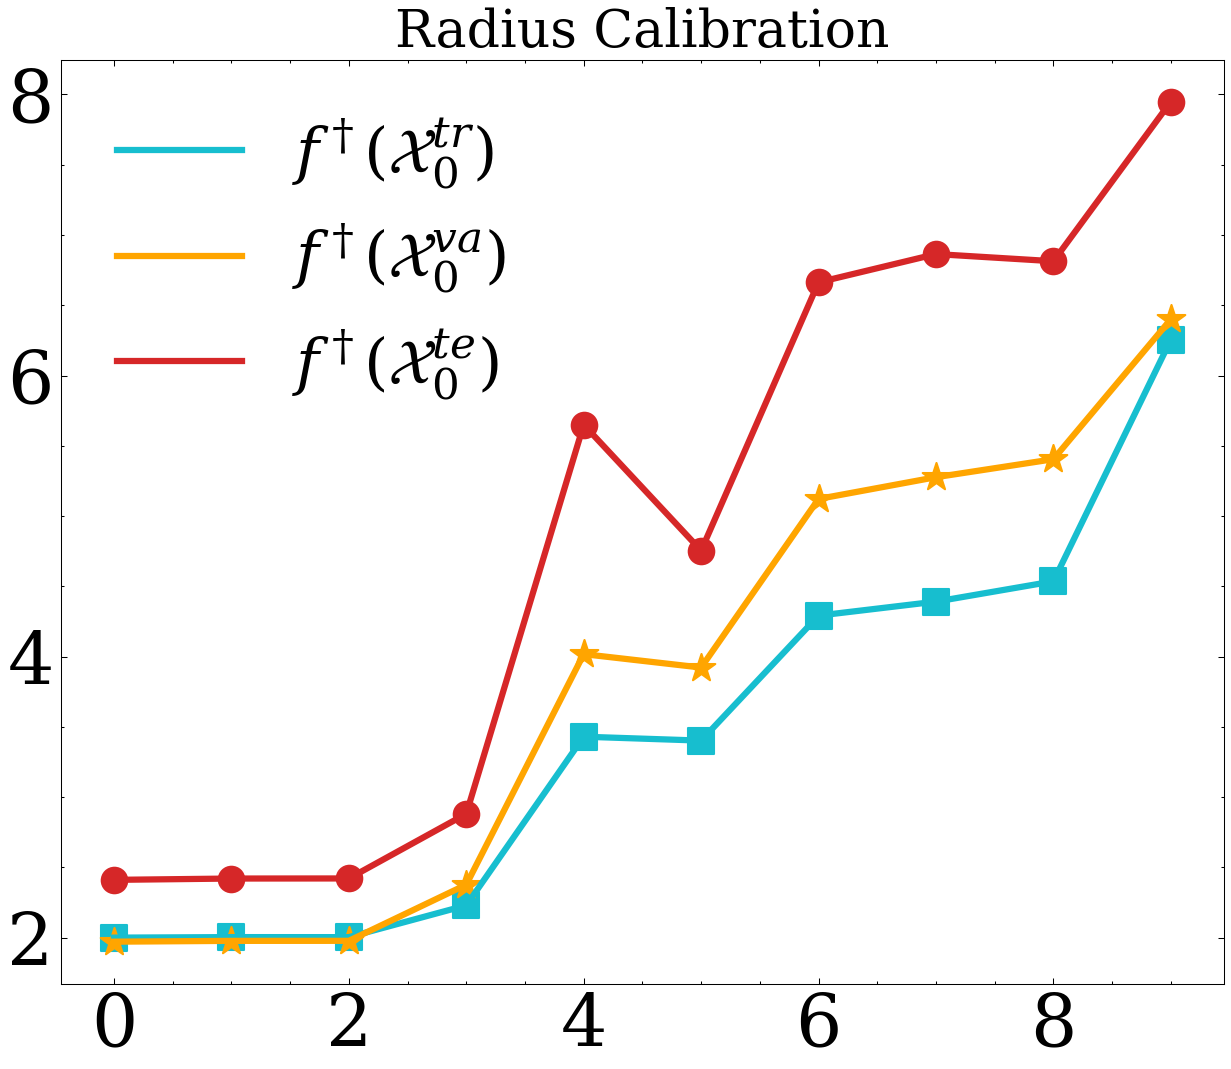

In [57]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_mass_train)), s_mass_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_mass_validation)), s_mass_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_mass_test)), s_mass_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Mass RMSE decay - Radius Analysis.png')
plt.legend(fontsize=30)
plt.show()

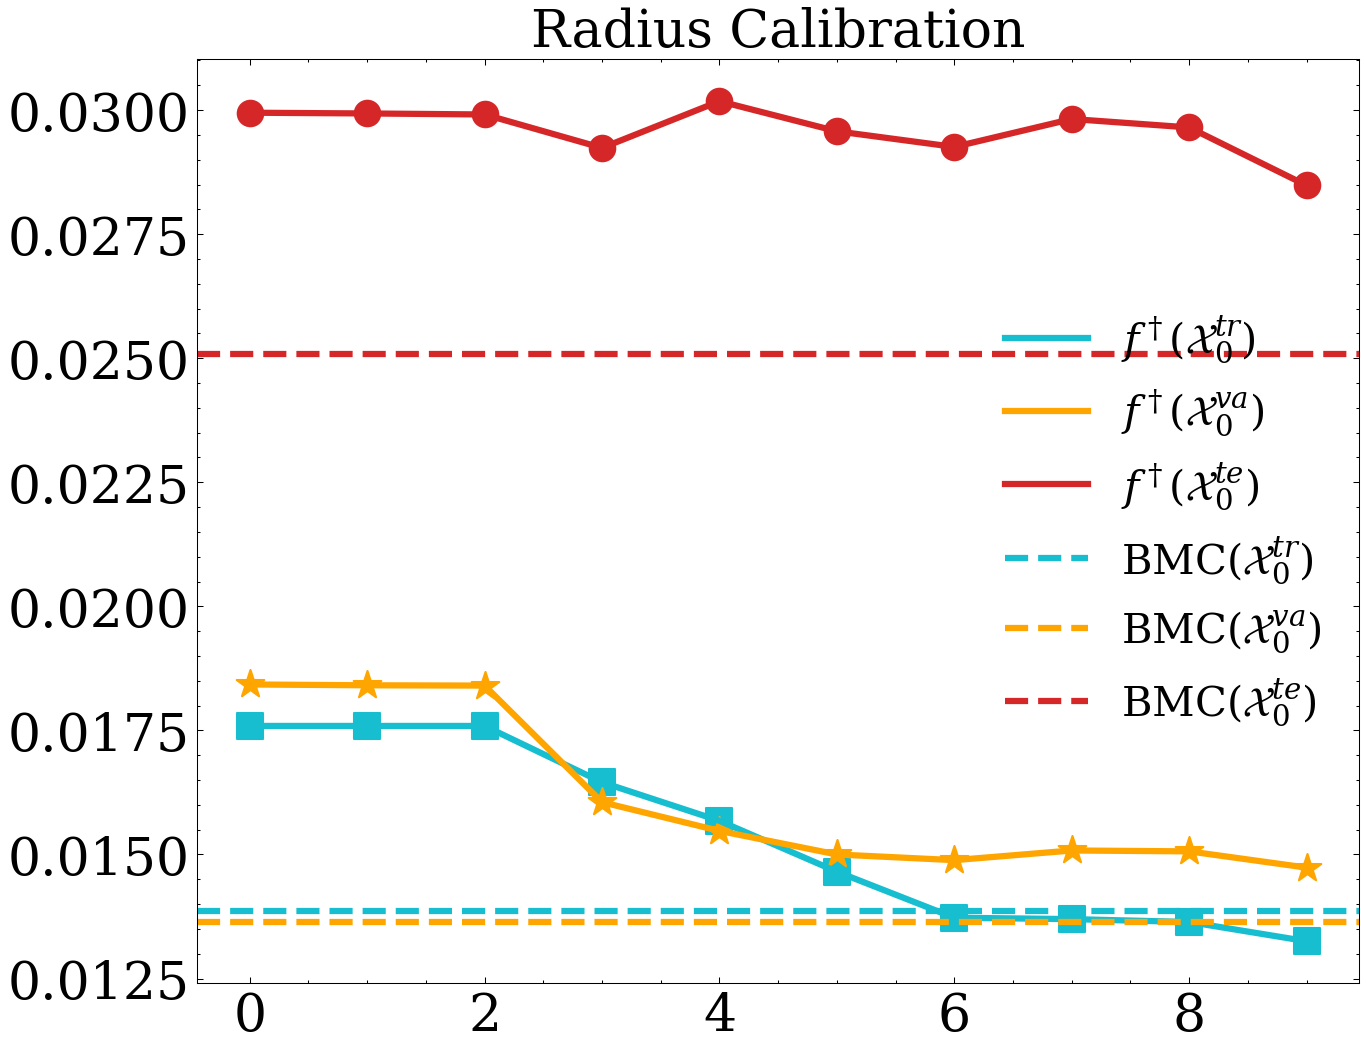

In [58]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

ax.axhline(y=supermodel_sigma_radius_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_validation,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_test,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Radius RMSE decay - Radius Analysis.png')
# plt.legend(fontsize=30)
plt.show()

In [59]:
s_mass_train

[2.000892414914846,
 2.0046213412797353,
 2.0044434880790636,
 2.230264822910876,
 3.430507969395531,
 3.4025662232422644,
 4.292044070105929,
 4.391539915571707,
 4.535766346108193,
 6.254533496190521]

The parameters that we get from OLS solution using all data space yields smaller RMSE (which is what we should expect). We still do not yet understand why the test RMSE does not decrease the more information (PCs) we feed into our calibration. 

This results indicate that somehow our models are very bad for the outer region of nuclei. What we can try to do next is to analyse the performace when we only find paramters from OLS of the training data. We should expect that this line is above 0.025, but if is very far away from this calculation then we would know that our models are somehow very bad in the outer regions

In [60]:
XTX_rad_train = model_predictions_radius_train.T.dot(model_predictions_radius_train)
XTX_rad_train_inv = np.linalg.inv(XTX_rad_train)
super_params_train = XTX_rad_train_inv.dot(model_predictions_radius_train.T).dot(models_output_radius_train['truth'])

In [61]:
XTX_rad_test = model_predictions_radius_test.T.dot(model_predictions_radius_test)
XTX_rad_test_inv = np.linalg.inv(XTX_rad_test)
super_params_test = XTX_rad_test_inv.dot(model_predictions_radius_test.T).dot(models_output_radius_test['truth'])

In [62]:
supermodel_radius_train_train = super_params_train.dot(model_predictions_radius_train.T)
supermodel_radius_validation_train = super_params_train.dot(model_predictions_radius_validation.T)
supermodel_radius_test_train = super_params_train.dot(model_predictions_radius_test.T)
supermodel_radius_full_train = super_params_train.dot(model_predictions_radius.T)

supermodel_residuals_radius_train_train=supermodel_radius_train_train-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_validation_train= supermodel_radius_validation_train-models_output_radius_validation['truth'].tolist()
supermodel_residuals_radius_test_train = supermodel_radius_test_train-models_output_radius_test['truth'].tolist()
supermodel_residuals_radius_full_train = supermodel_radius_full_train-models_output_radius['truth'].tolist()

supermodel_sigma_radius_train_train=np.sqrt(np.sum(supermodel_residuals_radius_train_train**2) / len(supermodel_residuals_radius_train_train) )
supermodel_sigma_radius_validation_train=np.sqrt(np.sum(supermodel_residuals_radius_validation_train**2) / len(supermodel_residuals_radius_validation_train) )
supermodel_sigma_radius_test_train=np.sqrt(np.sum(supermodel_residuals_radius_test_train**2) / len(supermodel_residuals_radius_test_train) )
supermodel_sigma_radius_full_train=np.sqrt(np.sum(supermodel_residuals_radius_full_train**2) / len(supermodel_residuals_radius_full_train) )

In [63]:
supermodel_radius_train_test = super_params_test.dot(model_predictions_radius_train.T)
supermodel_radius_test_test = super_params_test.dot(model_predictions_radius_test.T)

supermodel_residuals_radius_train_test=supermodel_radius_train_test-models_output_radius_train['truth'].tolist()
supermodel_residuals_radius_test_test=supermodel_radius_test_test-models_output_radius_test['truth'].tolist()

supermodel_sigma_radius_train_test=np.sqrt(np.sum(supermodel_residuals_radius_train_test**2) / len(supermodel_residuals_radius_train_test) )
supermodel_sigma_radius_test_test=np.sqrt(np.sum(supermodel_residuals_radius_test_test**2) / len(supermodel_residuals_radius_test_test) )

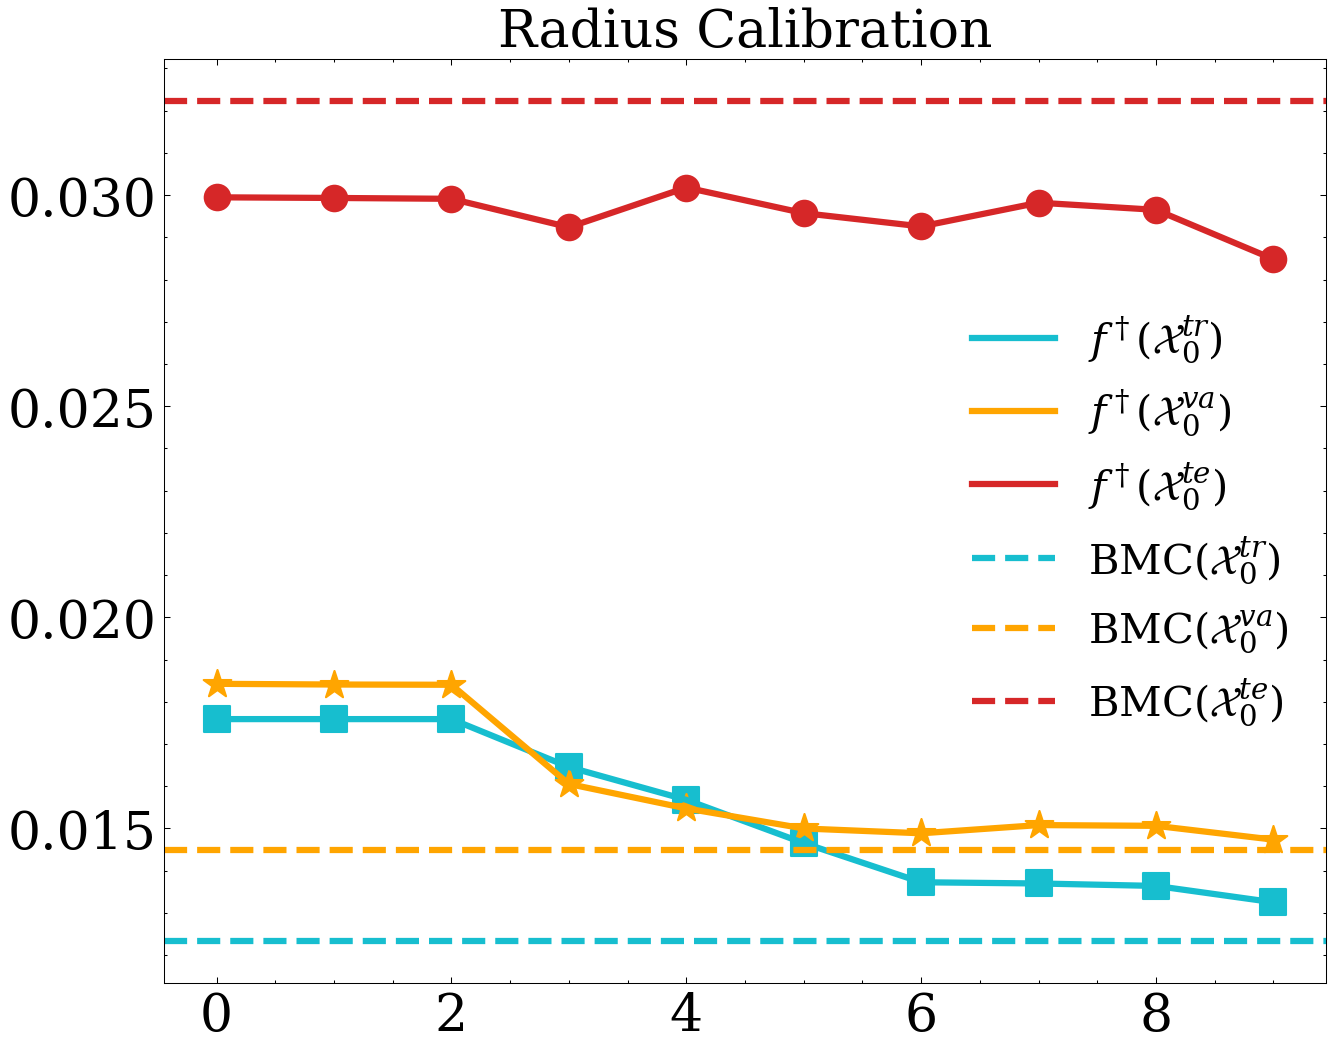

In [64]:
plt.rc("xtick", labelsize=25)
plt.rc("ytick", labelsize=25)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')




size_points=150


ax.scatter(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,s=size_points,marker=marker_train)
ax.plot(np.arange(0,len(s_radius_train)), s_radius_train,color=color_train,linewidth=3,label='$f^\dagger(\mathcal{X}_0^{tr})$')

ax.scatter(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_radius_validation)), s_radius_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,s=size_points,marker=marker_test)
ax.plot(np.arange(0,len(s_radius_test)), s_radius_test,color=color_test,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

ax.axhline(y=supermodel_sigma_radius_train_train,color=color_train,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_validation_train,color=color_validation,label="BMC$(\mathcal{X}_0^{va})$",linestyle='dashed',linewidth=3)
ax.axhline(y=supermodel_sigma_radius_test_train,color=color_test,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
# ax.set_xlabel(r'PC kept (p)',fontsize=40)
# ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
# ax.set_xticks([0,5,10,15])

# plt.ylim(2.5*10**(-1),2.3)

plt.legend(fontsize=20)
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')
plt.title('Radius Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/RMSE decays/Radius RMSE decay - Radius Analysis.png')
# plt.legend(fontsize=30)
plt.show()

We see that there is improvement in the trainign region, which is what we expect as we are only fitting to the training dataset. Let's now make a historgram comparing the RMSE of all the models and the combined one

In [48]:
def models_RMSE_radius_calculator(models_selected):
    models_RMSE_train = []
    models_RMSE_validation = []
    models_RMSE_test = []
    models_RMSE_full = []

    for model in models_selected:
        residuals_train=models_output_radius_train[model]-models_output_radius_train['truth'].tolist()
        residuals_validation= models_output_radius_validation[model]-models_output_radius_validation['truth'].tolist()
        residuals_test = models_output_radius_test[model]-models_output_radius_test['truth'].tolist()
        residuals_full = models_output_radius[model]-models_output_radius['truth'].tolist()
    
        sigma_train=np.sqrt(np.sum(residuals_train**2) / len(residuals_train) )
        sigma_validation=np.sqrt(np.sum(residuals_validation**2) / len(residuals_validation) )
        sigma_test=np.sqrt(np.sum(residuals_test**2) / len(residuals_test) )
        sigma_full=np.sqrt(np.sum(residuals_full**2) / len(residuals_full) )

        models_RMSE_train.append(sigma_train)
        models_RMSE_validation.append(sigma_validation)
        models_RMSE_test.append(sigma_test)
        models_RMSE_full.append(sigma_full)
        
    return models_RMSE_train, models_RMSE_validation, models_RMSE_test, models_RMSE_full

In [49]:
models_RMSE_radius_train, models_RMSE_radius_validation, models_RMSE_radius_test, models_RMSE_radius_full = models_RMSE_radius_calculator(models_selected)

In [53]:
models_RMSE_radius_full

[0.02706544564248088,
 0.034898832254871004,
 0.029094156492824905,
 0.029877184839155194,
 0.024974454963689052,
 0.032353523255802735,
 0.026734629804426126,
 0.024491833106603893,
 0.02420129843983401,
 0.028315959480604665]

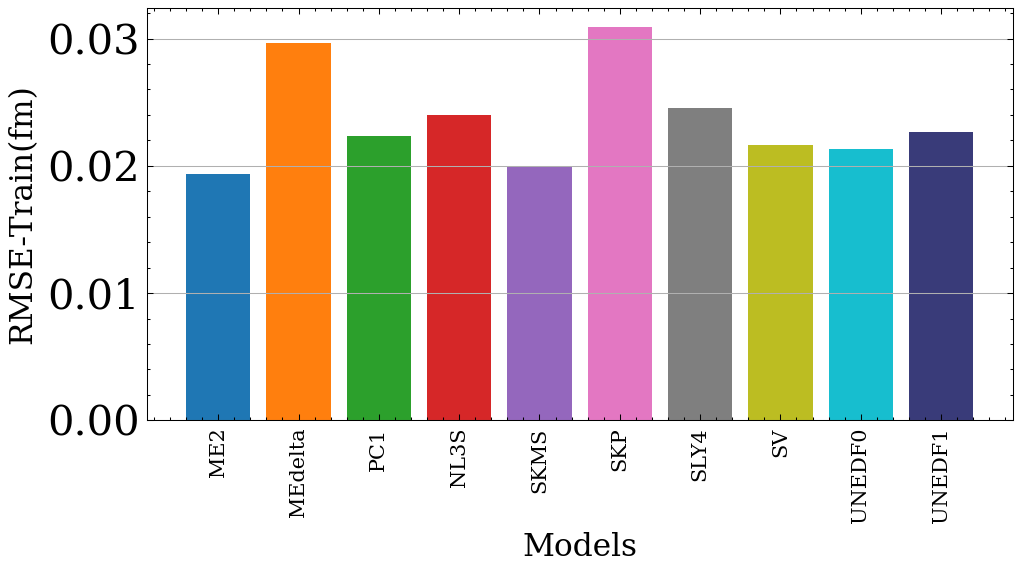

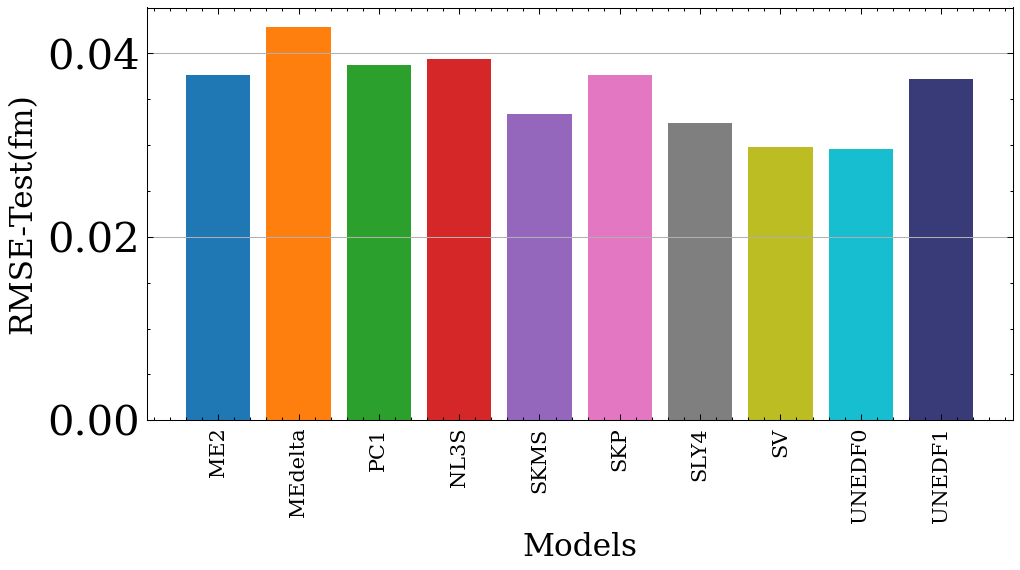

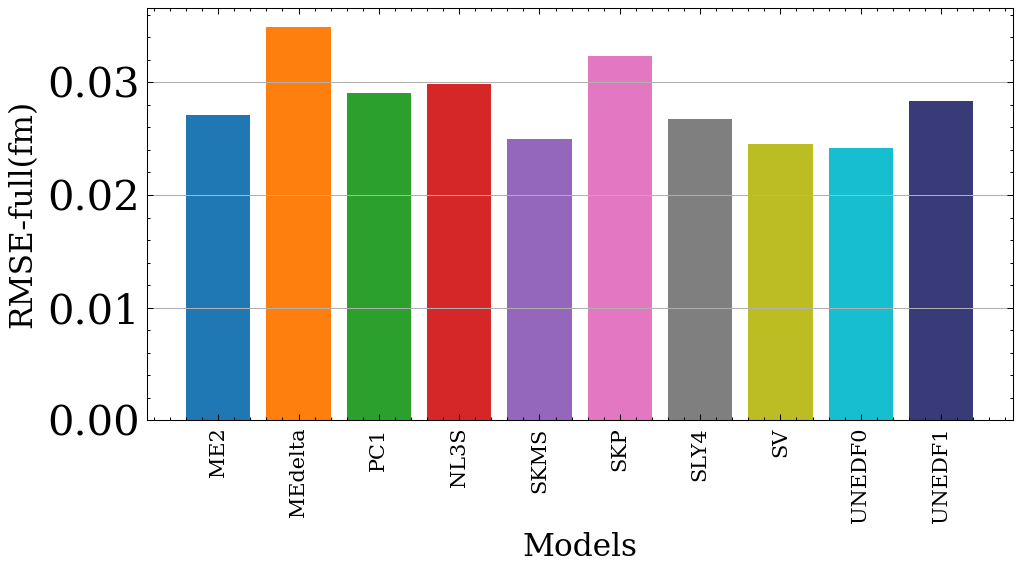

In [52]:
y_max = 0.05

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_radius_train[i], color = colors[i])
    i+=1
# plt.bar('Supermodel - Full', supermodel_sigma_radius_train, color = 'm')
# plt.bar('Supermodel - Train', supermodel_sigma_radius_train_train, color = 'k')
# plt.bar('Supermodel - Test', supermodel_sigma_radius_train_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-Train(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data/Models RMSE/Models RMSE training region.png')
plt.show()

#############################
# test region ###############

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_radius_test[i], color = colors[i])
    i+=1
# plt.bar('Supermodel - Full', supermodel_sigma_radius_test, color = 'm')
# plt.bar('Supermodel - Train', supermodel_sigma_radius_test_train, color = 'k')
# plt.bar('Supermodel - Test', supermodel_sigma_radius_test_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-Test(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data/Models RMSE/Models RMSE testing region.png')
plt.show()

##############################
# full region ################

plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
plt.figure(figsize=(7, 4),dpi=150)
i = 0
for model in models_selected:
    plt.bar(model, models_RMSE_radius_full[i], color = colors[i])
    i+=1
# plt.bar('Supermodel - Full', supermodel_sigma_radius_test, color = 'm')
# plt.bar('Supermodel - Train', supermodel_sigma_radius_test_train, color = 'k')
# plt.bar('Supermodel - Test', supermodel_sigma_radius_test_test, color = 'forestgreen')

plt.xlabel('Models',fontsize=15)
plt.ylabel('RMSE-full(fm)',fontsize=15)
# plt.ylim(0,y_max)
plt.xticks(fontsize=10,rotation='vertical')
plt.grid(axis='y')
plt.tight_layout()
# plt.savefig('Plots/Radii data/Models RMSE/Models RMSE testing region.png')
plt.show()


By looking at these results, we can see that the models that we had right now does not have a good predictions for charge radii in outer regions. 

### What we are going to do now is to graph the CR predictions of these models for different isotopes. We want to see how identical these models are in CR predictions

In [70]:
# In this cell, I am going to extract a bunch of models predictions for different isotopes 
x = np.linspace(20,90,8)
filtered_models_output_radius_dict = {}
for j in x:
    print(j)
    key = f"filtered_models_output_radius_list_{int(j)}"
    filtered_models_output_radius_dict[key] = filtered_models_output(int(j), models_output_radius, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_models_output_radius_dict.keys()

20.0
30.0
40.0
50.0
60.0
70.0
80.0
90.0


dict_keys(['filtered_models_output_radius_list_20', 'filtered_models_output_radius_list_30', 'filtered_models_output_radius_list_40', 'filtered_models_output_radius_list_50', 'filtered_models_output_radius_list_60', 'filtered_models_output_radius_list_70', 'filtered_models_output_radius_list_80', 'filtered_models_output_radius_list_90'])

In [108]:
x = np.linspace(20,90,8)
filtered_predictions_mean_radius_dict = {}
for j in x:
    key = f"filtered_predictions_mean_radius_list_{int(j)}"
    filtered_predictions_mean_radius_dict[key] = filtered_models_output(int(j), predictions_mean_radius_df, train_coordinates_radius, validation_coordinates_radius, test_coordinates_radius)
filtered_predictions_mean_radius_dict.keys()

dict_keys(['filtered_predictions_mean_radius_list_20', 'filtered_predictions_mean_radius_list_30', 'filtered_predictions_mean_radius_list_40', 'filtered_predictions_mean_radius_list_50', 'filtered_predictions_mean_radius_list_60', 'filtered_predictions_mean_radius_list_70', 'filtered_predictions_mean_radius_list_80', 'filtered_predictions_mean_radius_list_90'])

In [96]:
filtered_models_output_radius_dict[dict_keys[0]][1]

,N,Z,A,ME2,MEdelta,PC1,NL3S,SKMS,SKP,SLY4,SV,UNEDF0,UNEDF1,truth
23,20,20,40,3.465,3.425,3.457,3.470,3.508447,3.530085,3.508657,3.501743,3.501457,3.483709,3.4776
24,22,20,42,3.469,3.435,3.463,3.468,3.513530,3.536751,3.515920,3.505667,3.503420,3.487649,3.5081
25,24,20,44,3.474,3.447,3.472,3.469,3.517619,3.543701,3.522998,3.510855,3.505047,3.494824,3.5179
26,26,20,46,3.479,3.459,3.481,3.472,3.523560,3.552996,3.531629,3.519449,3.511087,3.505986,3.4953
27,28,20,48,3.481,3.468,3.490,3.474,3.533390,3.564701,3.543605,3.531471,3.521495,3.520582,3.4771


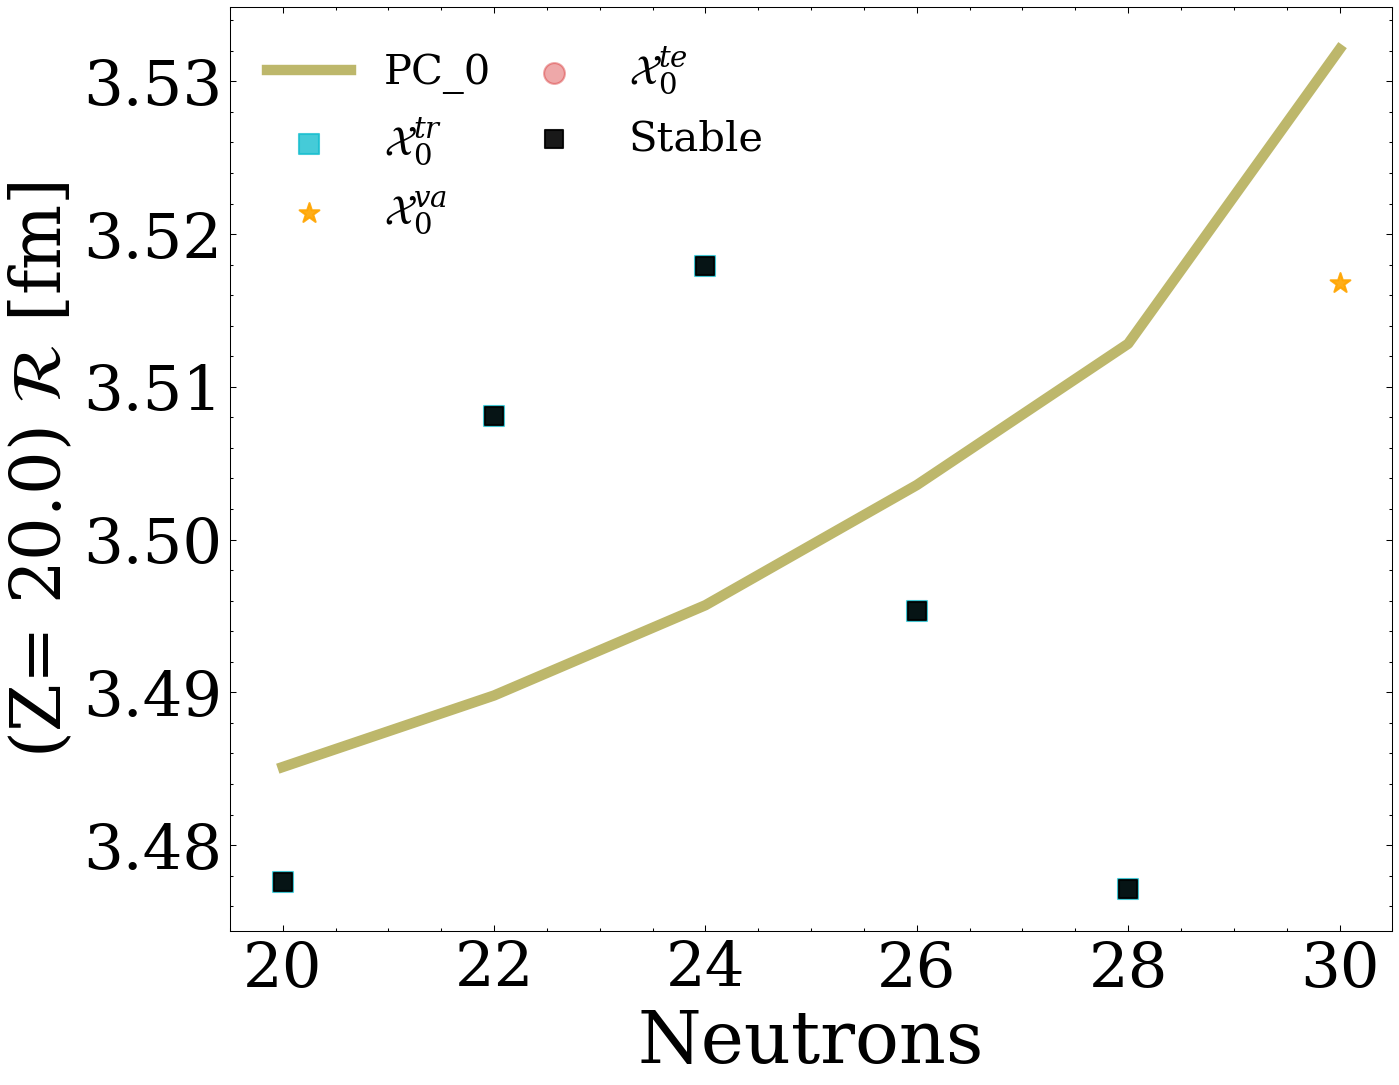

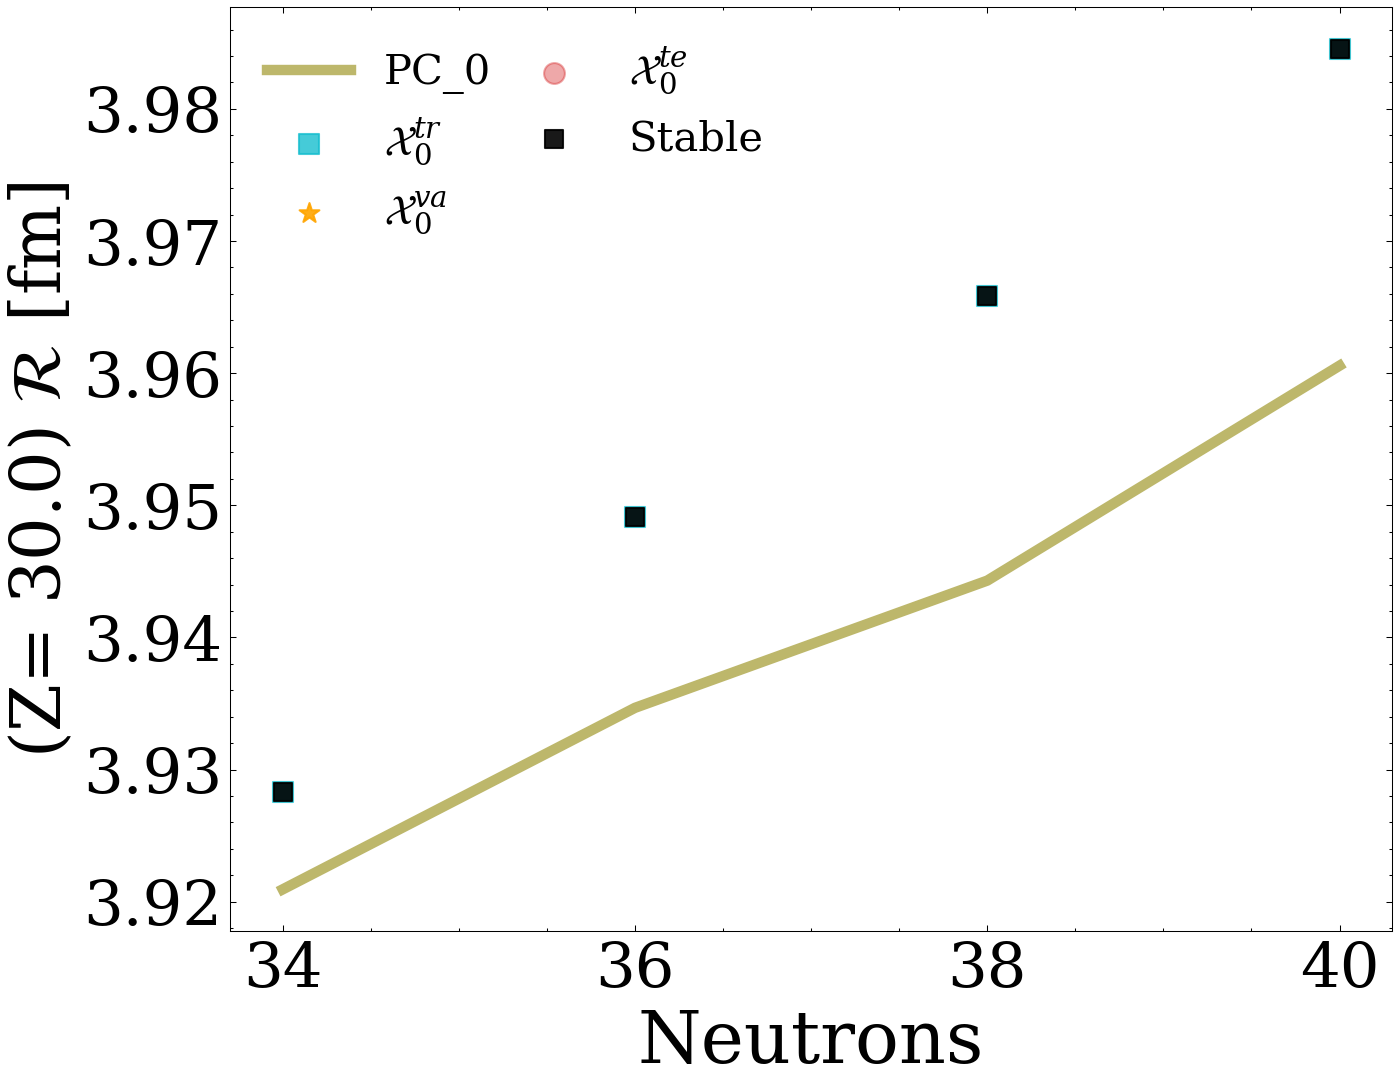

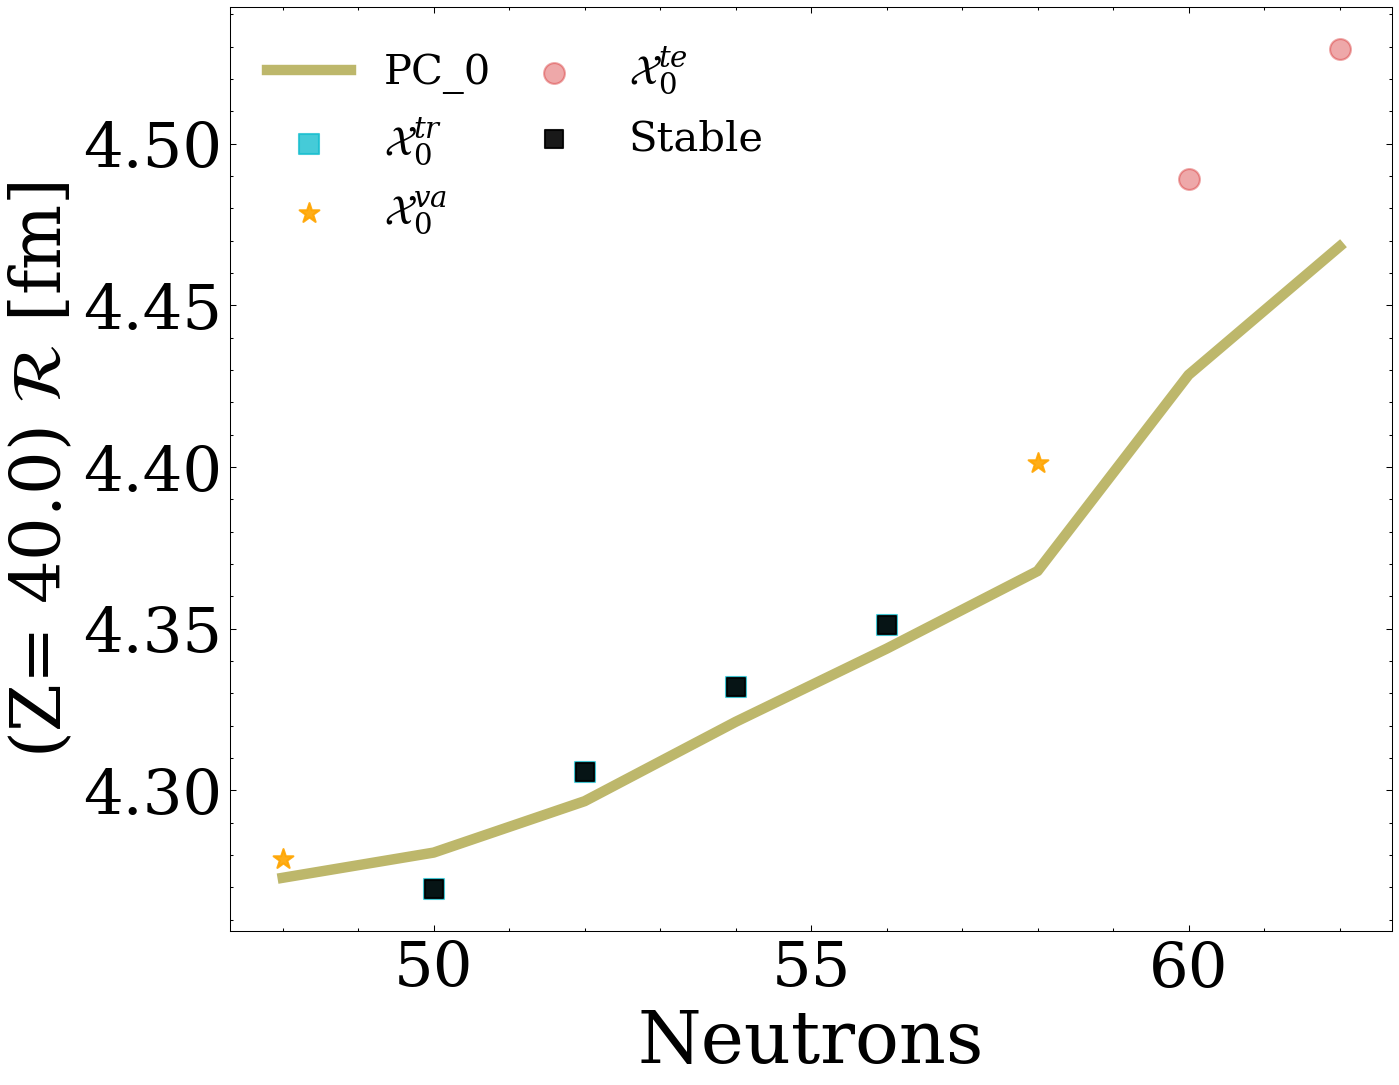

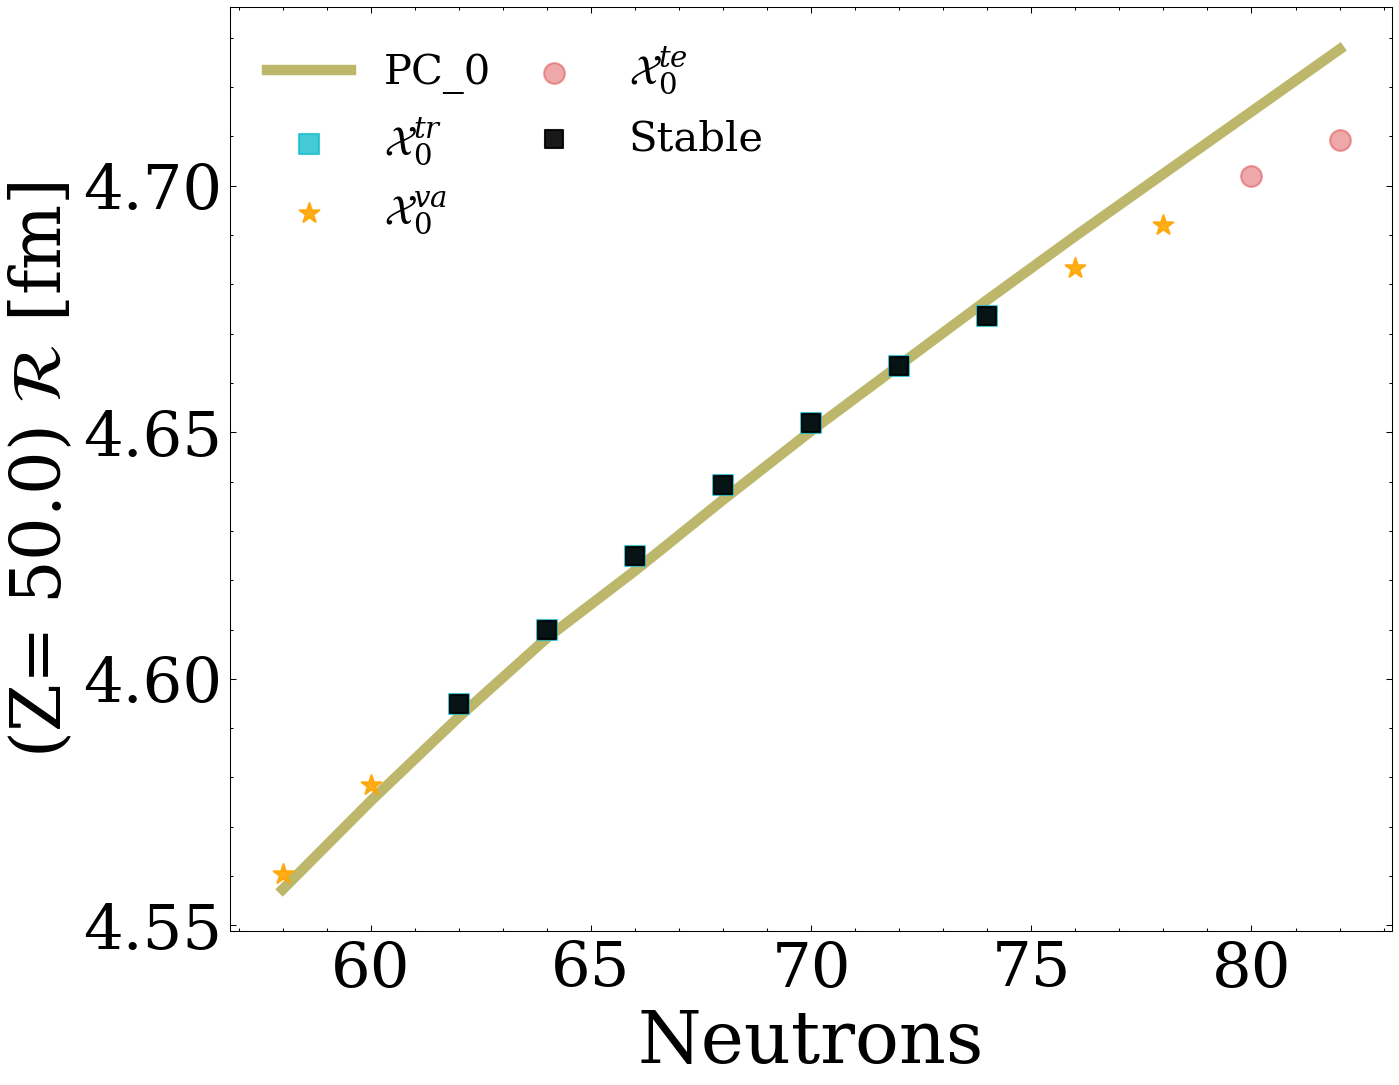

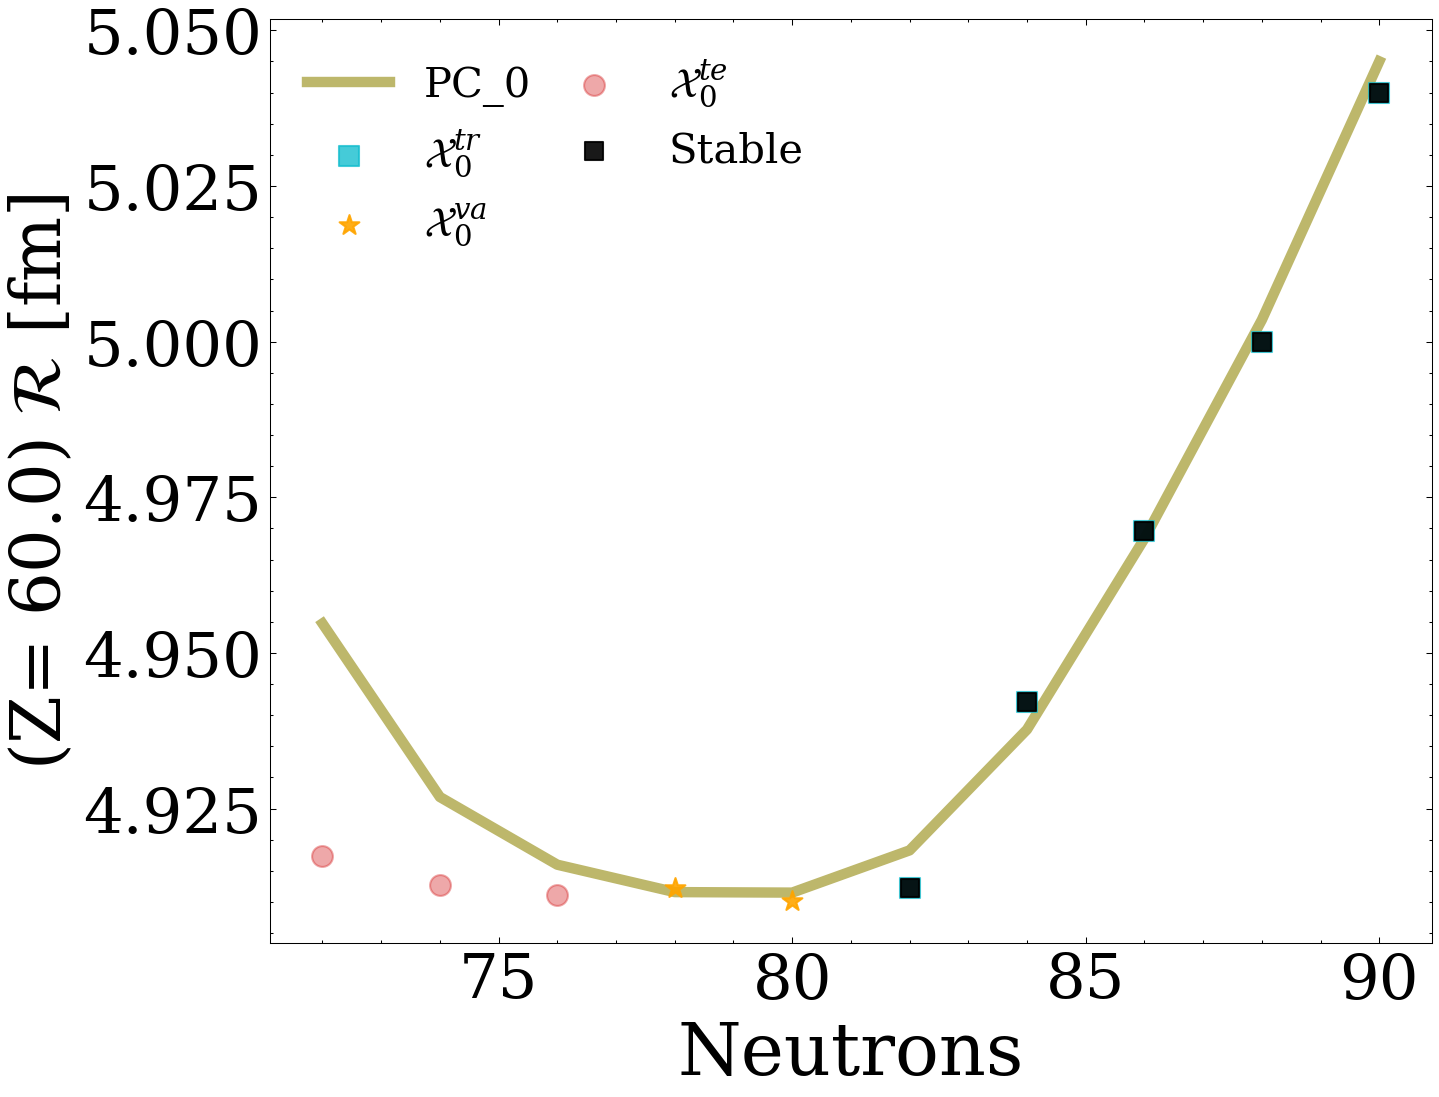

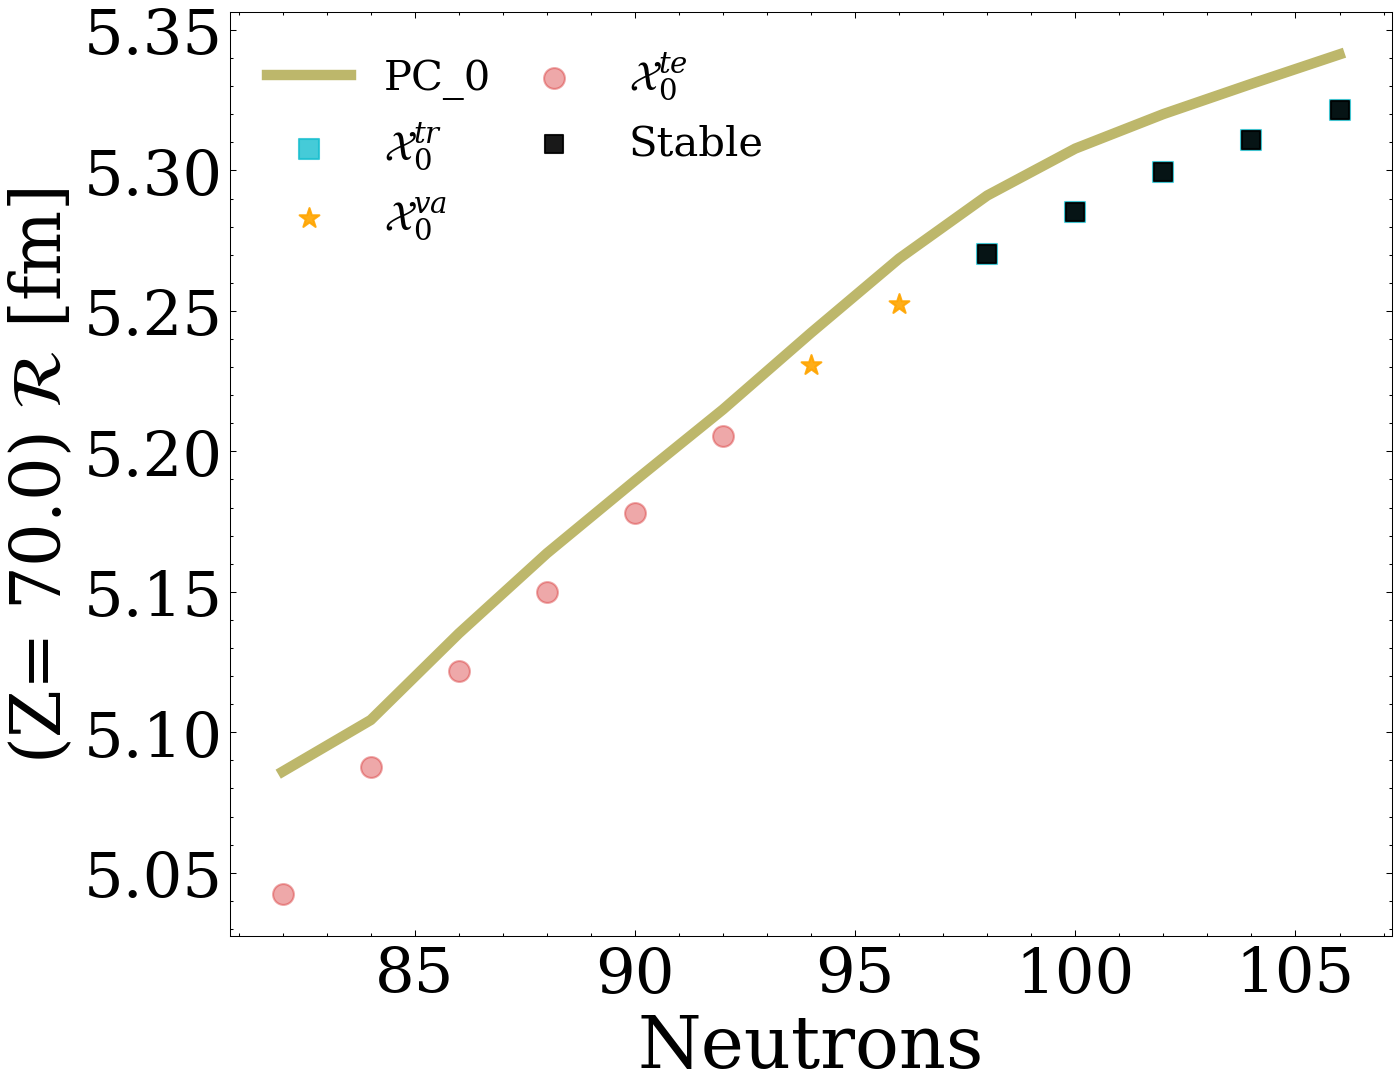

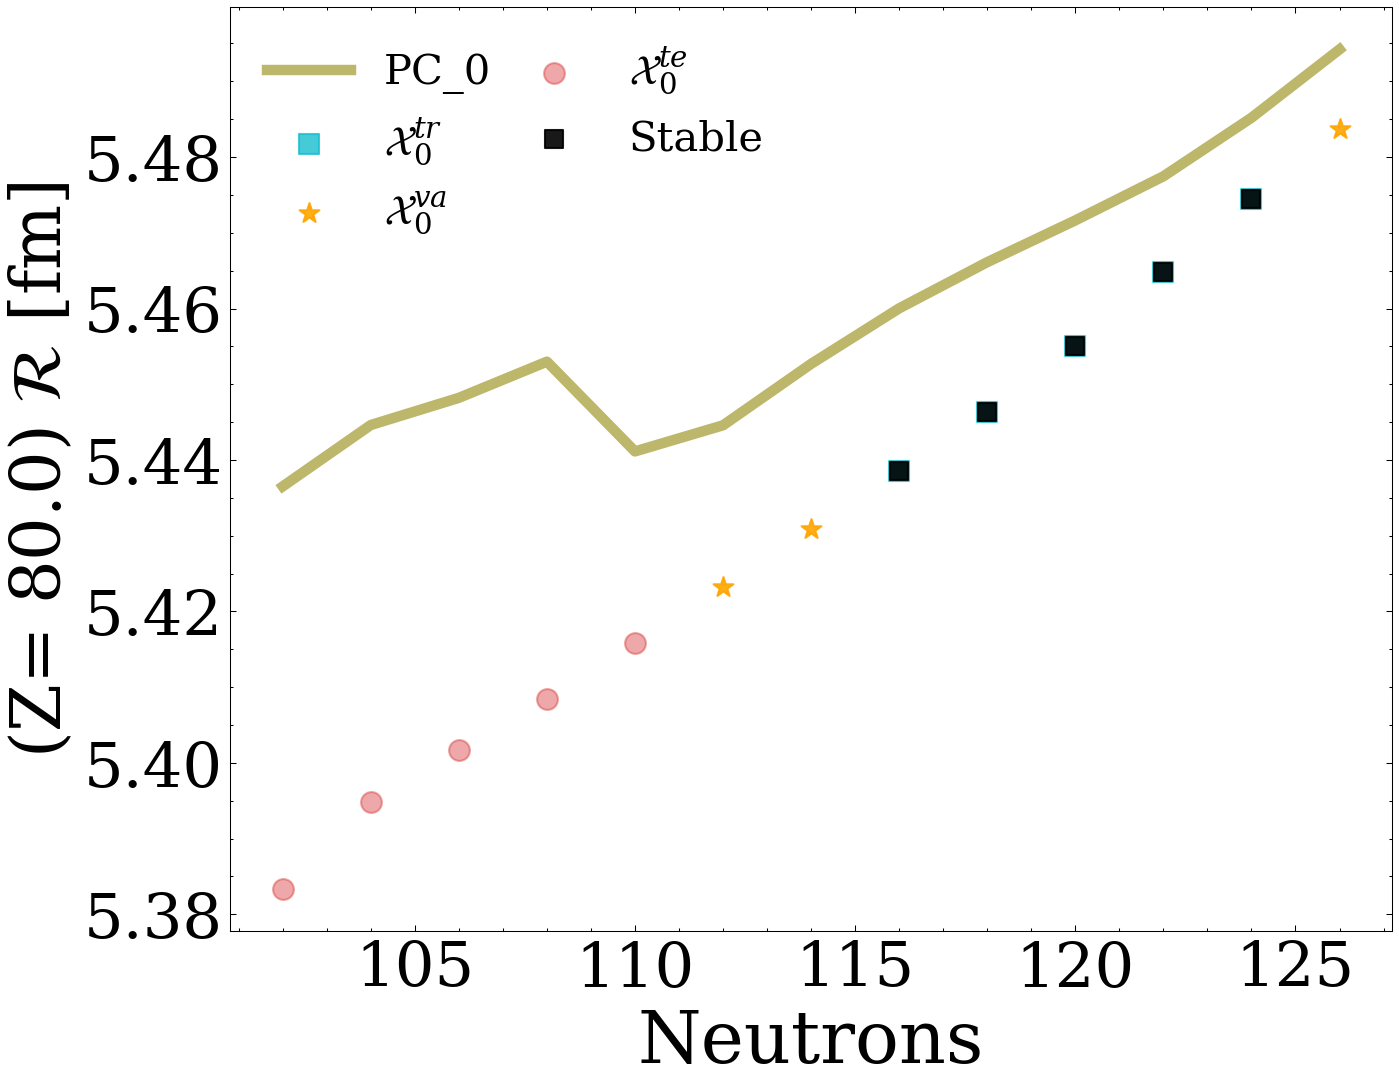

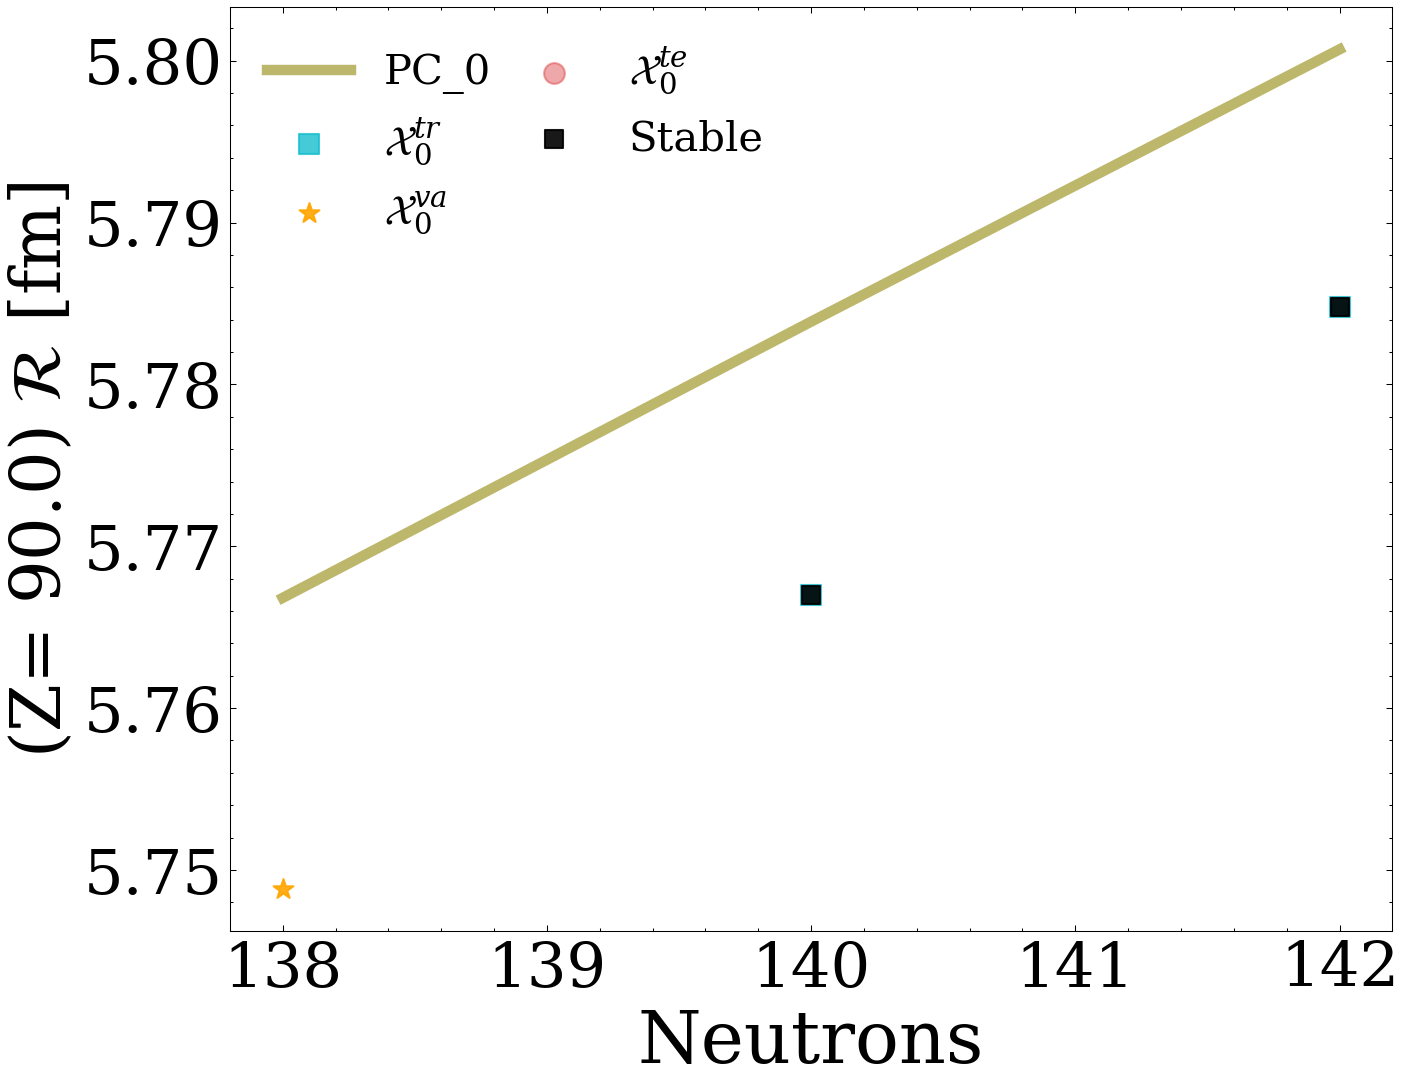

In [110]:
x = np.linspace(20,90,8)
Selected_element_list = ['Ca', 'Zn', 'Zr', 'Sn', 'Nd', 'Yb', 'Hg', 'Th']
dict_keys_mean = list(filtered_predictions_mean_radius_dict.keys())
dict_keys = list(filtered_models_output_radius_dict.keys())

i = 0
for key in dict_keys_mean:
    plt.rc("xtick", labelsize=30)
    plt.rc("ytick", labelsize=30)
    
    plt.rcParams['text.usetex'] = False
    plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
    
    fig, ax = plt.subplots(figsize=(10,8), dpi=150)
    # This gives you the mean predictions of the isotope that we choose
    plt.plot(filtered_predictions_mean_radius_dict[key][0]["N"], filtered_predictions_mean_radius_dict[key][0]['PC_0'] , color="darkkhaki", label='PC_0',linewidth=5)

    color_local= "khaki"

    # This gives you training predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][1]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][1]['truth'], label = "$\mathcal{X}_0^{tr}$",  alpha = alpha_train,color=color_train,s=100,marker=marker_train,zorder=2)
    # This gives you validation predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][2]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][2]['truth'], label = "$\mathcal{X}_0^{va}$", alpha=alpha_validation ,color=color_validation,s=100,marker=marker_validation,zorder=2)
    # This gives you testing predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][3]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][3]['truth'], label = "$\mathcal{X}_0^{te}$", alpha = alpha_test,color=color_test,s=100,marker=marker_test,zorder=2)
    # This gives you stable predictions for these isotope
    ax.scatter(x = filtered_models_output_radius_dict[dict_keys[i]][4]["N"], y = filtered_models_output_radius_dict[dict_keys[i]][4]['truth'], label = "Stable", alpha = 0.9,color='k',s=80,marker="s",zorder=2)
    
    plt.xlabel("Neutrons",fontsize=35)
    plt.ylabel(f"(Z= {x[i]}) $ {{\\cal R}}$ [fm]", fontsize=33)
    # plt.ylabel(Selected_element_name+ " BE/A MeV",fontsize=25)
         
    plt.legend(fontsize=20,markerscale=1,ncol=2,columnspacing=0.5)
    
    # plt.title(f'{title}', fontsize = 25)
    # plt.savefig(f'{save_fig}')
    plt.show()

    i = i+1

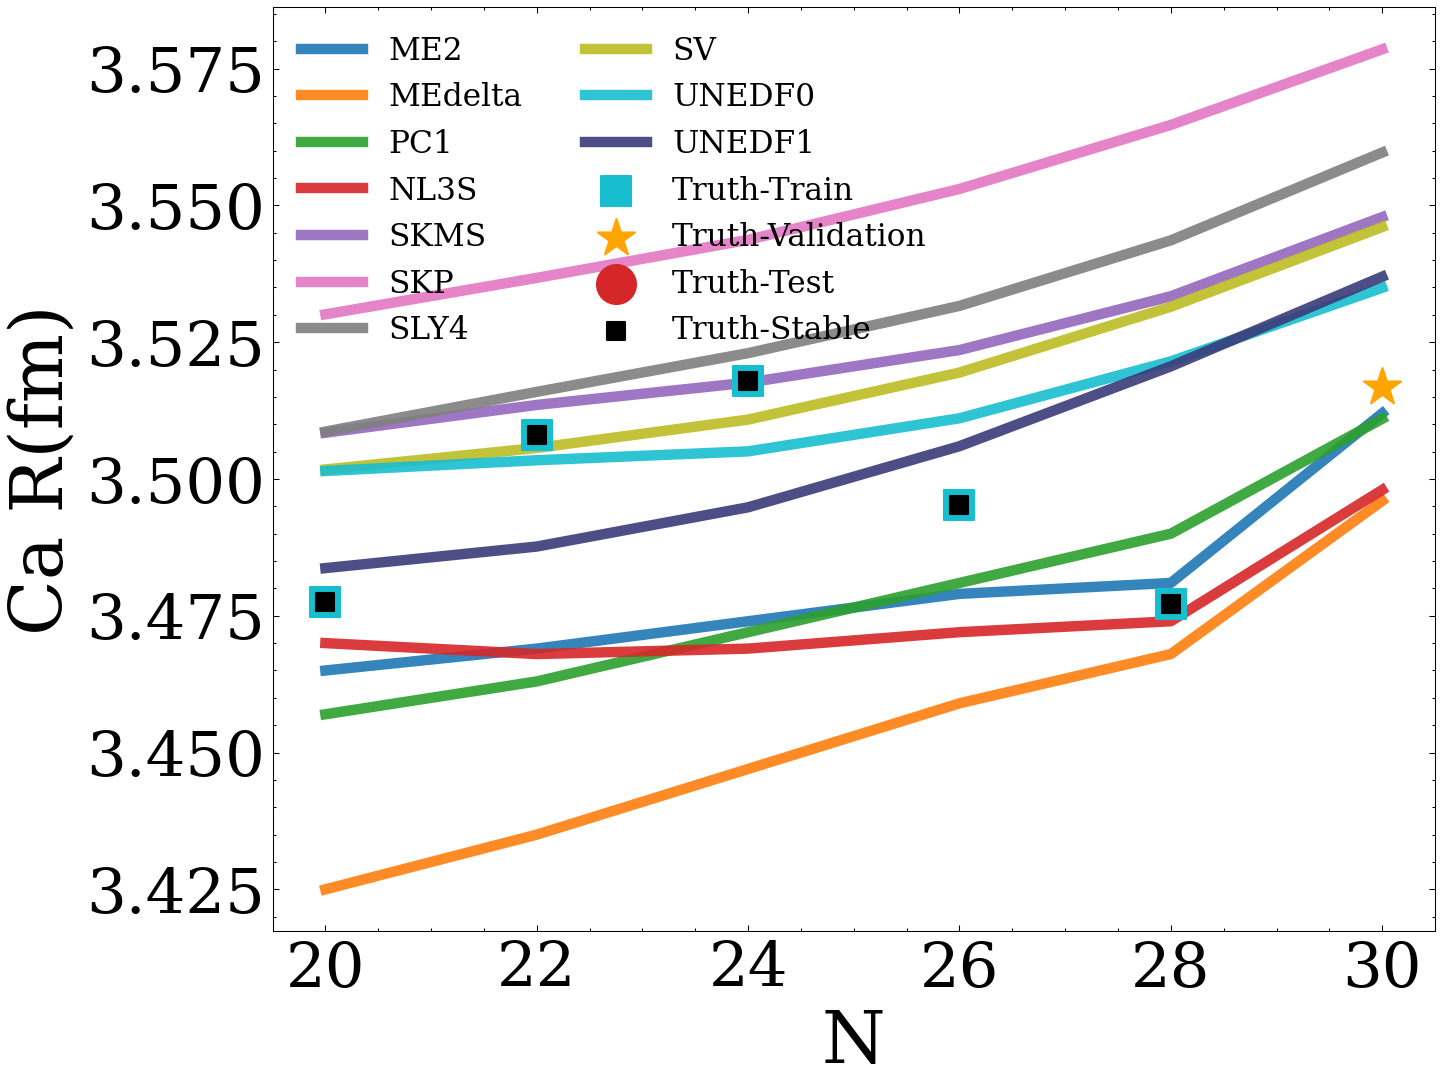

In [106]:
# savefig_Ca = 'Plots/Radii data/CR predictions for Ca.png'
plot_model_predictions(filtered_models_output_radius_dict[dict_keys[0]], models_selected, Selected_element_list[0])

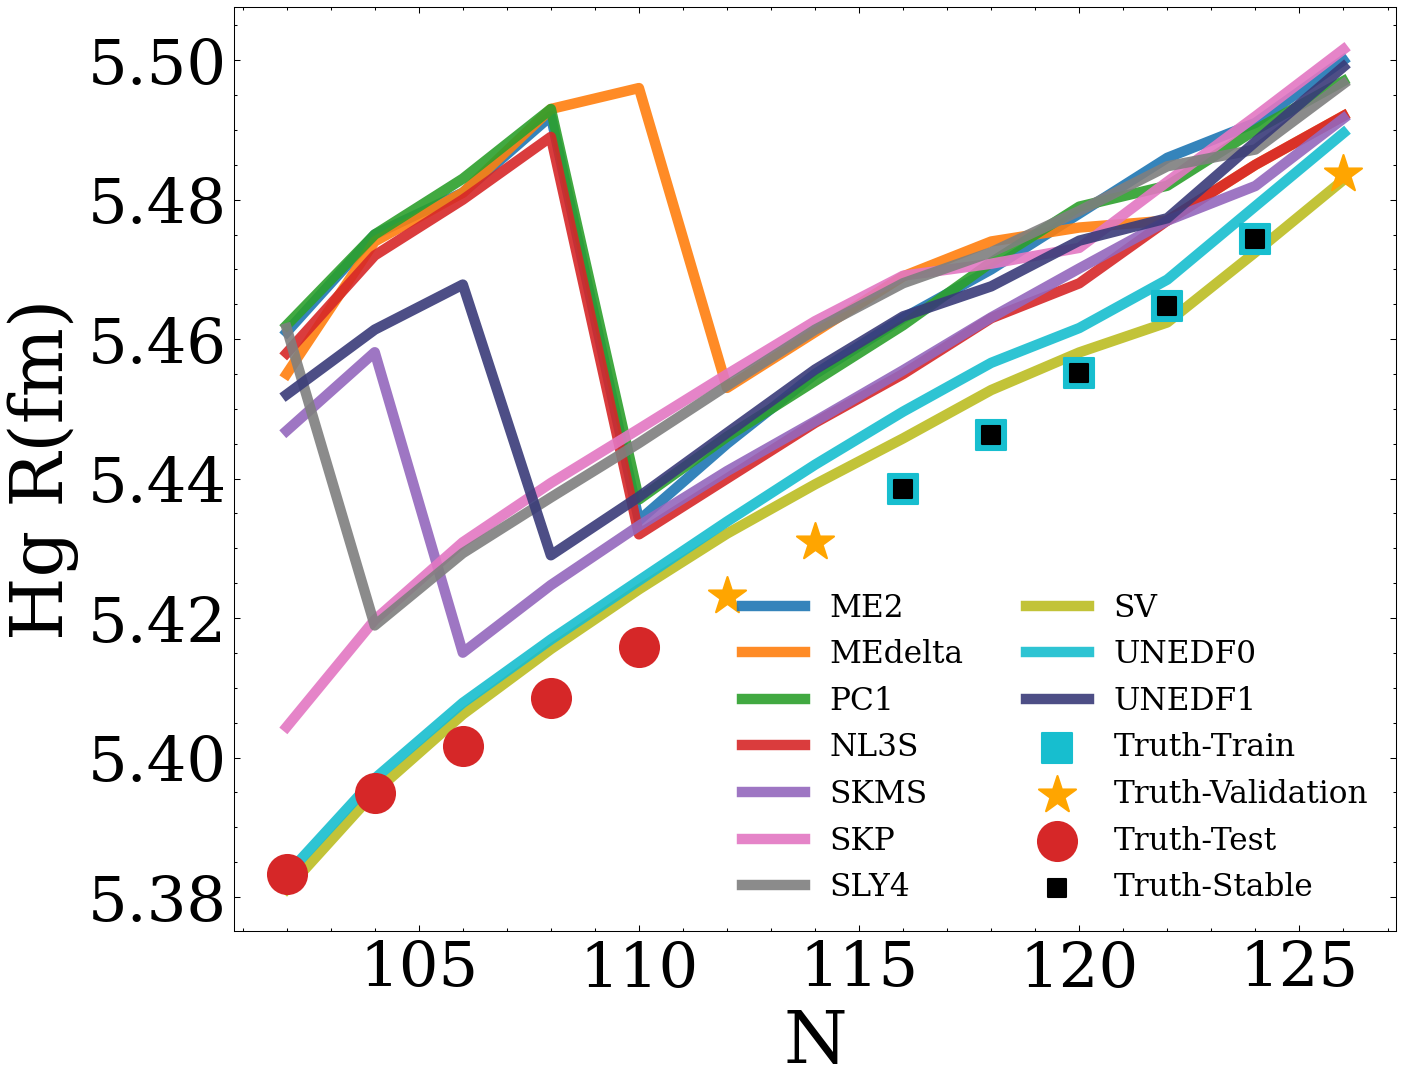

In [109]:
# savefig_Hg = 'Plots/Radii data/CR predictions for Hg.png'
plot_model_predictions(filtered_models_output_radius_dict[dict_keys[6]], models_selected, Selected_element_list[6])

Some comments that we have for the CR predictions of models for different nuclei. One thing that we can see is for Ca, there is no model that can capture the periodic behaviour of the CR change. In general, UNEDF0 is a pretty good model in predicting CR for heavier nuclei. We also see a strange behaviour of the models space for Hg.

In general, I think the models space was giving pretty decent predictions for heavier nuclei except for Hg. We will make a heat map that indicates the residuals of models to the actual experimental data points. If we see bright color in light nuclei regions, then let's try to explore how the BMM framework perform when we only include medium nuclei or above in our analysis

In [ ]:
# We are going to calculate the residuals of models to real experimental data points and graph a heat map
model_resdiuals_radius = models_output_radius[models_selected].subtract(models_output_radius['truth'], axis = 0)

In [ ]:
# savefig_heatmap_CR_residuals_ME2 = 'Plots/Radii data/Residuals heat map ME2'
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], model_resdiuals_radius['ME2'], 'CR residuals', 'ME2')

In [ ]:
# savefig_heatmap_CR_residuals_UNEDF0 = 'Plots/Radii data/Residuals heat map UNEDF0'
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], model_resdiuals_radius['UNEDF0'], 'CR residuals', 'UNEDF0')

### The next steps will be making the heat map of the PCs to check if there are something odd happening

In [ ]:
components_kept = 9
U_hat = np.array([U.T[i] for i in range(components_kept)]).T
S_hat = S[:components_kept]
Vt_hat = np.array([Vt[i]/S[i] for i in range(components_kept)])
Vt_hat_normalized=np.array([Vt[i] for i in range(components_kept)])
# Vt_hat = np.array([Vt[i] for i in range(components_kept)])

In [ ]:
models_PC_radius = {}
if centering_data:
    models_PC_radius[str("PC_0")] = predictions_mean_radius       
for i in range(components_kept):
    models_PC_radius[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_radius.T)

In [ ]:
savefig_heatmap_PC_0 = 'Plots/Radii data/PCs heat map/PC_0 heat map.png'
savefig_heatmap_PC_1 = 'Plots/Radii data/PCs heat map/PC_1 heat map.png'
savefig_heatmap_PC_2 = 'Plots/Radii data/PCs heat map/PC_2 heat map.png'
savefig_heatmap_PC_7 = 'Plots/Radii data/PCs heat map/PC_7 heat map.png'
savefig_heatmap_PC_8 = 'Plots/Radii data/PCs heat map/PC_8 heat map.png'

In [ ]:
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_0'], 'PC_0', 'PC_0')
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_1'], 'PC_1', 'PC_1')
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_2'], 'PC_2', 'PC_2')
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_7'], 'PC_7', 'PC_7')
plot_heatmap(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_8'], 'PC_8', 'PC_8')

### Let's now plot naive supermodel for different number of PCs. We see that the RMSE does not change for the first 2 PCs

In [73]:
naive_supermodel_residuals_0_PC = predictions_mean_radius - models_output_radius['truth']
naive_supermodel_residuals_1_PC = supermodel_residuals_radius_calculator(1)
naive_supermodel_residuals_2_PCs = supermodel_residuals_radius_calculator(2)
naive_supermodel_residuals_7_PCs = supermodel_residuals_radius_calculator(7)
naive_supermodel_residuals_8_PCs = supermodel_residuals_radius_calculator(8)

In [74]:
savefig_heatmap_CR_residuals_0_PC = 'Plots/Radii data/BMM CR residuals heat map/Naive BMM residuals heat map for 0 PC.png'
savefig_heatmap_CR_residuals_1_PC = 'Plots/Radii data/BMM CR residuals heat map/Naive BMM residuals heat map for 1 PC.png'
savefig_heatmap_CR_residuals_2_PCs = 'Plots/Radii data/BMM CR residuals heat map/Naive BMM residuals heat map for 2 PCs.png'
savefig_heatmap_CR_residuals_7_PCs = 'Plots/Radii data/BMM CR residuals heat map/Naive BMM residuals heat map for 7 PCs.png'
savefig_heatmap_CR_residuals_8_PCs = 'Plots/Radii data/BMM CR residuals heat map/Naive BMM residuals heat map for 8 PCs.png'

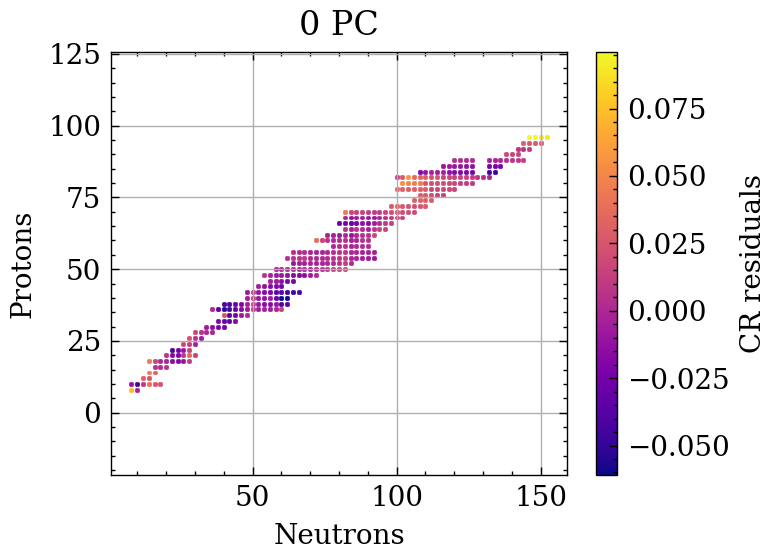

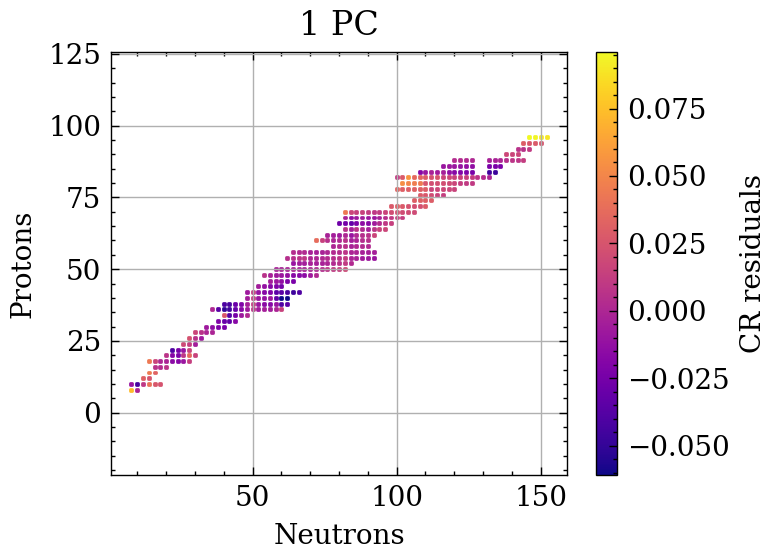

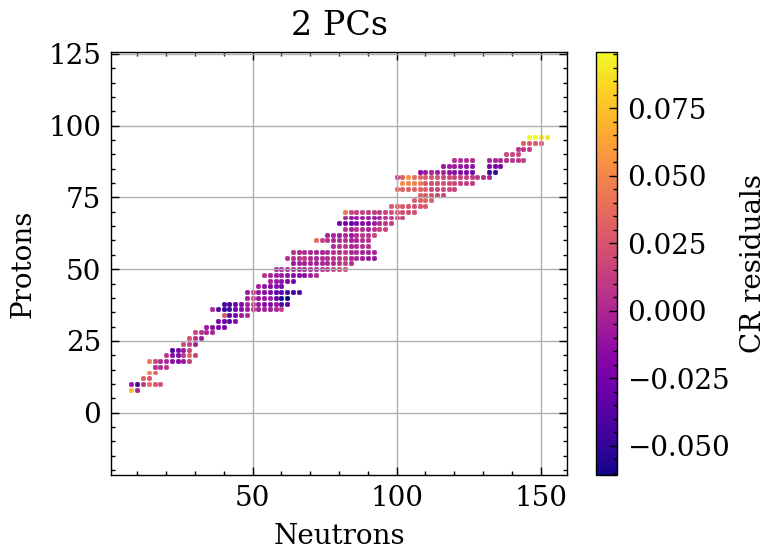

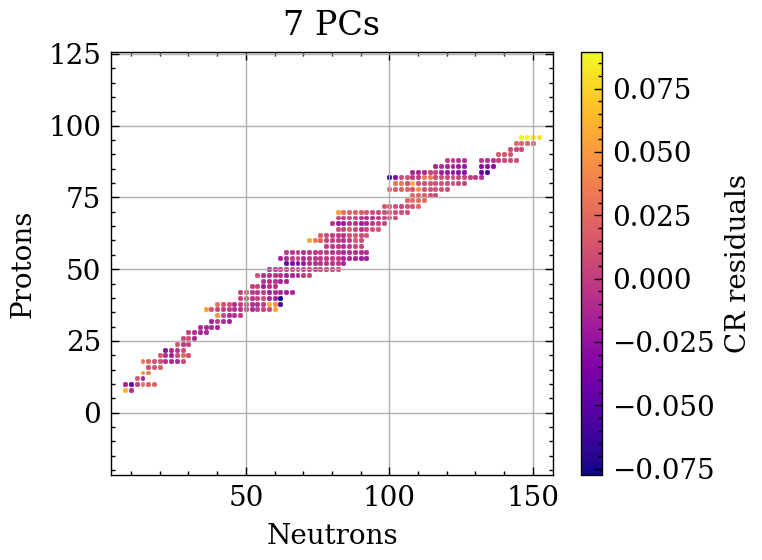

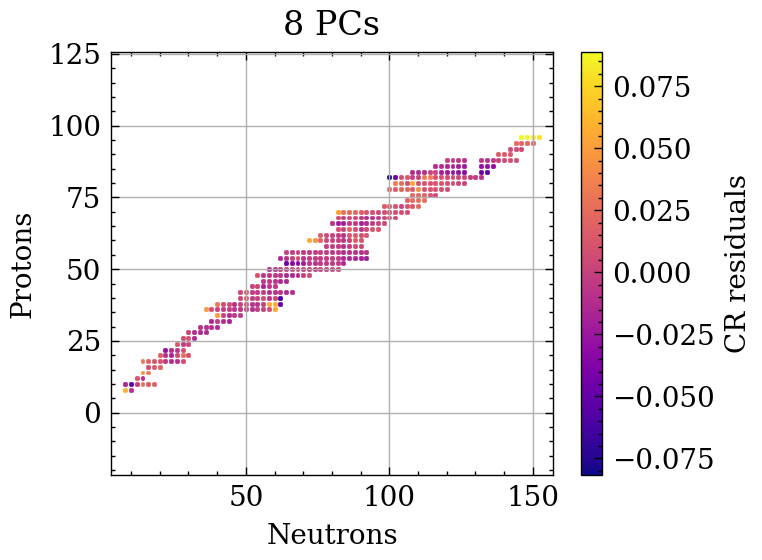

In [75]:
plot_heatmap_savefig(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], naive_supermodel_residuals_0_PC, 'CR residuals', '0 PC', savefig_heatmap_CR_residuals_0_PC)
plot_heatmap_savefig(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], naive_supermodel_residuals_1_PC, 'CR residuals', '1 PC', savefig_heatmap_CR_residuals_1_PC)
plot_heatmap_savefig(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], naive_supermodel_residuals_2_PCs, 'CR residuals', '2 PCs', savefig_heatmap_CR_residuals_2_PCs)
plot_heatmap_savefig(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], naive_supermodel_residuals_7_PCs, 'CR residuals', '7 PCs', savefig_heatmap_CR_residuals_7_PCs)
plot_heatmap_savefig(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], naive_supermodel_residuals_8_PCs, 'CR residuals', '8 PCs', savefig_heatmap_CR_residuals_8_PCs)

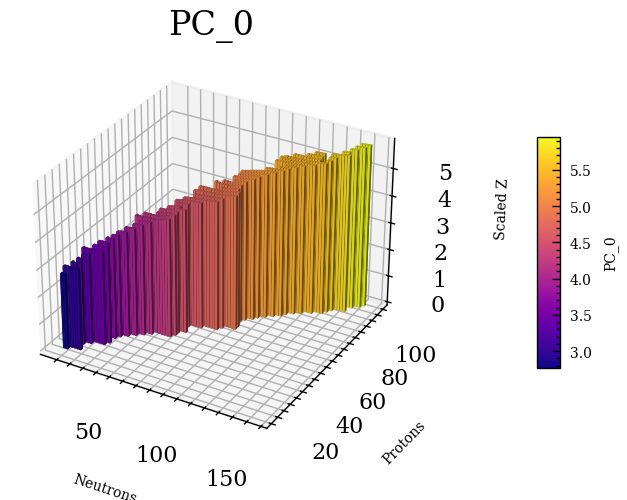

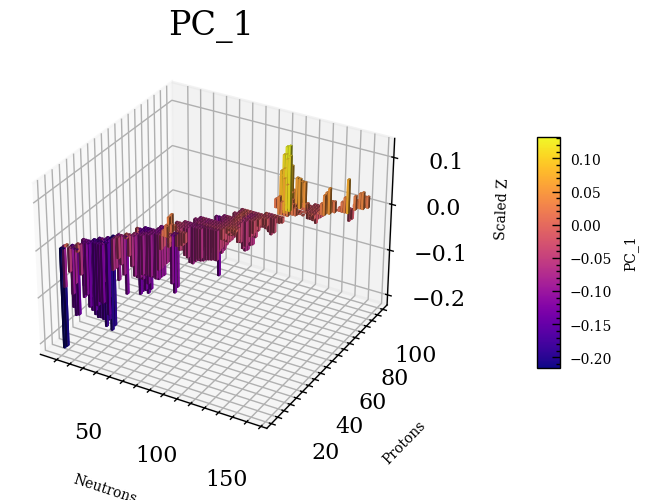

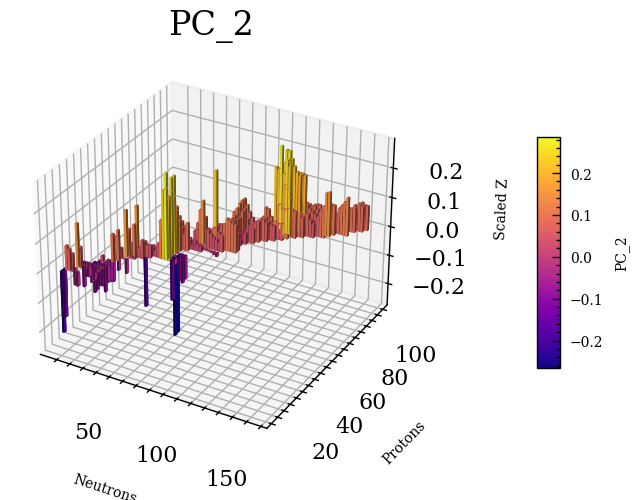

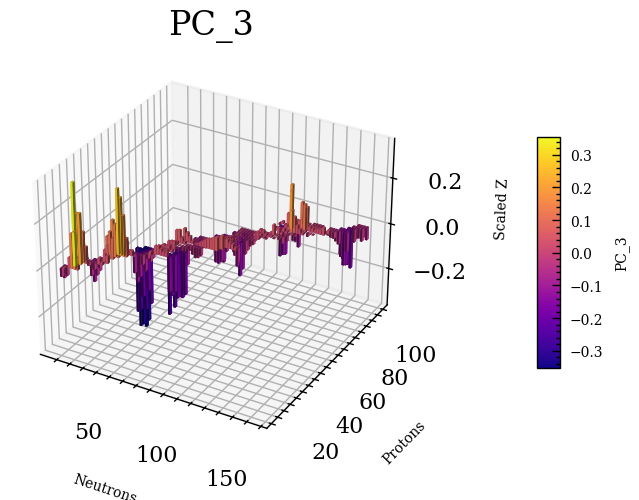

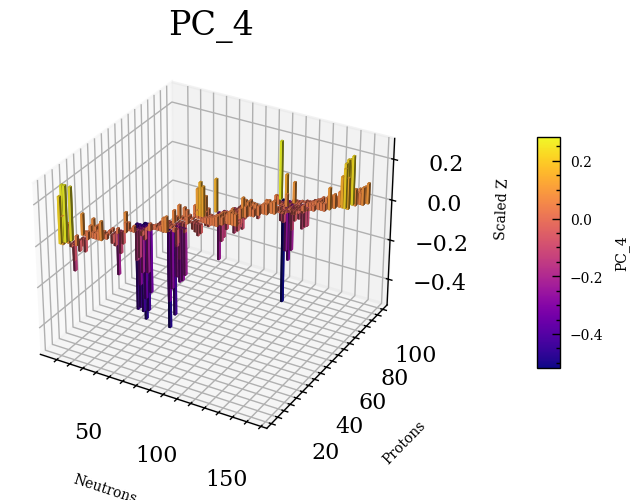

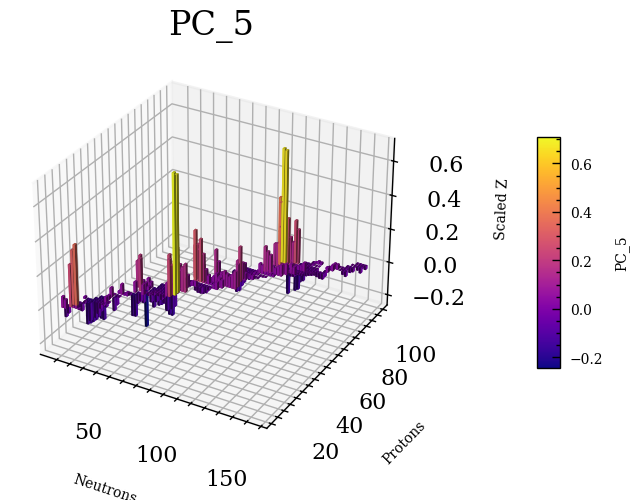

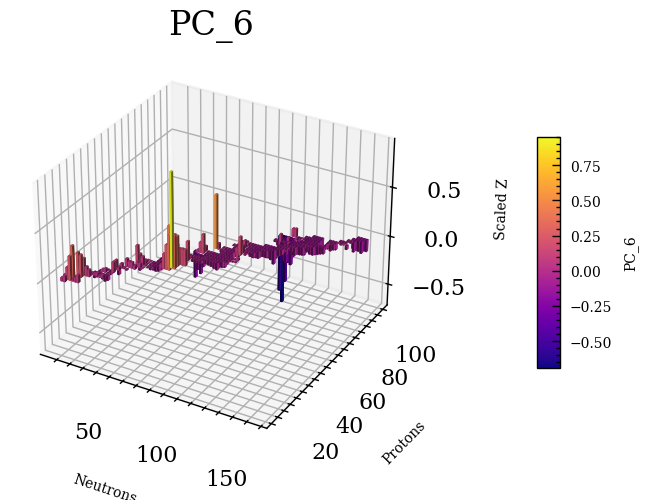

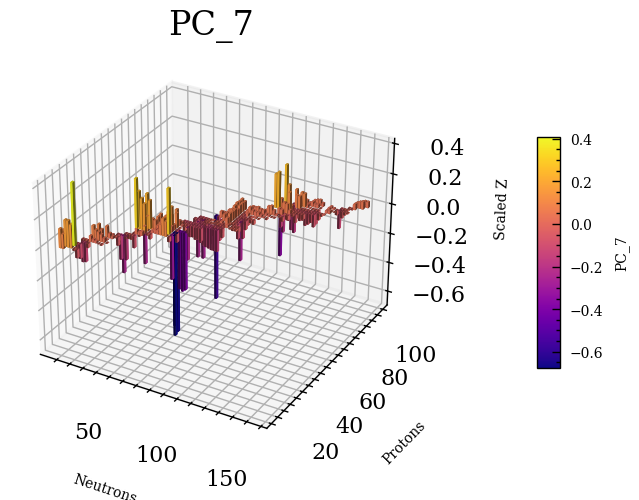

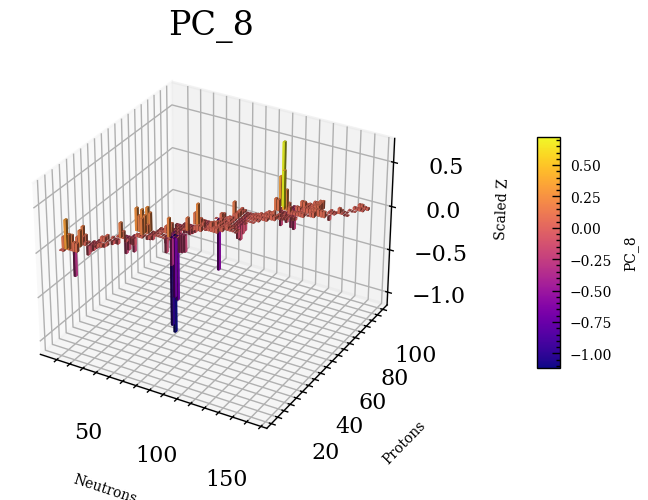

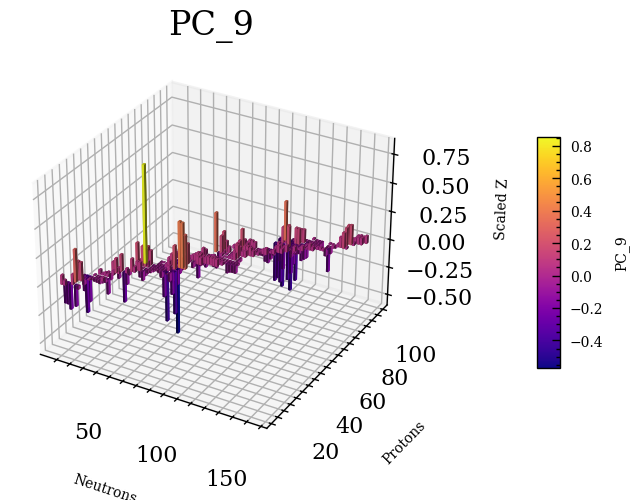

In [95]:
# plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_0'], 'PC_0', elev=30,azim=-60)
# plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_1'], 'PC_1', elev=30,azim=-60)
# plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_2'], 'PC_2', elev=30,azim=-60)
# plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_7'], 'PC_7', elev=30,azim=-60)
# plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius['PC_8'], 'PC_8', elev=30,azim=-60)
for PC in list(models_PC_radius.keys()):
    plot_heatmap_3D(filtered_NZ_df_radius['N'], filtered_NZ_df_radius['Z'], models_PC_radius[PC], PC, elev=30,azim=-60)

In [ ]:
plot_filtered_supermodel(supermodel_predictions_range, filtered_models_output_list, Z, unit, property, Constraint, title)

In [162]:
filtered_NZ_df_radius['Z'].max()

96

### We do not yet understand why the RMSE changes strangely like this. The first 2 PCs barely changes anything. Let's now continue with 2PCs to make it sync with our mass analysis

### The first plots we are going to show is the plots of projections of models onto the PCs. We will compare this graph between the 3 cases to see if there is any discrepancies between the 3 analysis

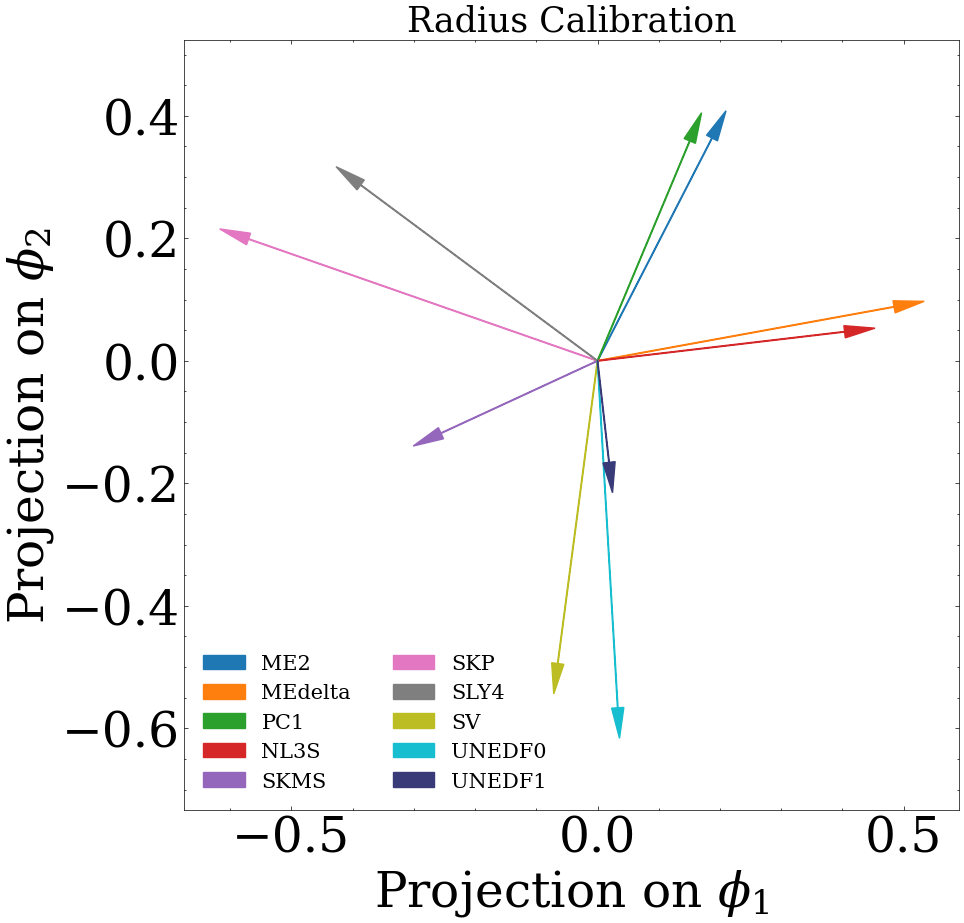

In [261]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,10), dpi=100)


visited_model=0
for model in key_list:
    ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
            head_width=0.02, head_length=0.05, fc=colors[visited_model], ec=colors[visited_model],label=model)
#     plt.text(Vt_hat_normalized.T[visited_model][0], Vt_hat_normalized.T[visited_model][1], model,fontsize=20,ha='center', va='center')    
    # ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
    #     head_width=0.02, head_length=0.05, fc='w', ec='w',label=model)

    # ax.arrow(0, 0, Vt_hat_normalized.T[visited_model][0],Vt_hat_normalized.T[visited_model][1], 
    #         head_width=0.02, head_length=0.05, fc=colors[visited_model], ec=colors[visited_model],label=str(visited_model))

    visited_model=visited_model+1



plt.xlabel('Projection on $\phi_1$',fontsize=35)
plt.ylabel('Projection on $\phi_2$',fontsize=35)

plt.xticks(fontsize=35)
plt.yticks(fontsize=35)


plt.legend(fontsize=15,ncols=2)
# ax.set_xticks([-0.2,0,0.2,0.4,0.6])
plt.axis('equal')
# plt.xlim(-0.25, 0.6)
# plt.ylim(-0.43, 0.5)
plt.title('Radius Calibration', fontsize = 25)
# plt.savefig('Plots/Heterogeneous Real Scaled Analysis/PCs projections/Projections on PCs - Radius Analysis.png')

plt.show()


In [262]:
X = np.copy(U_hat)

y_mass = models_output_mass_train['truth'] - predictions_mean_mass_train
y_radius = models_output_radius_train['truth'] - predictions_mean_radius_train
y = np.hstack((y_mass,y_radius))

X_train = models_PC_radius_train.values
X_validation = models_PC_radius_validation.values
X_test = models_PC_radius_test.values
X_full = models_PC_radius.values

In [263]:
X.shape

(167, 2)

## We will now consider the both unconstrained and simplex-constrained sampling method

### Unconstrained

In [264]:
nu0_chosen=1
sigma20_chosen=0.05

In [265]:
def gibbs_sampler(y, X, iterations,prior_info):
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
    b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), 
    #nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    b_mean_cov_inv=np.linalg.inv(b_mean_cov)
    n = len(y) # We are still taking mass and radius to be the same size
    
    X_T_X=X.T.dot(X)
    X_T_X_inv = np.linalg.inv(X_T_X)

    b_data = X_T_X_inv.dot(X.T).dot(y)

    
    
    supermodel=X.dot(b_data)
    

    residuals = y - supermodel 

    
    
    sigma2 = np.sum(residuals**2) / len(residuals) 
    cov_matrix = sigma2 * X_T_X_inv
    
    samples = []
    
    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data

        
        cov_matrix = np.linalg.inv(X_T_X/sigma2
                                   + b_mean_cov_inv)
        
        mean_vector = cov_matrix.dot(        b_mean_cov_inv.dot(b_mean_prior)+ X.T.dot(y)/sigma2  )
        
        
        b_current = np.random.multivariate_normal(mean_vector, cov_matrix)

        
        
        
        # Sample from the conditional posterior of sigma2 given bs and data
        supermodel=X.dot(b_current)
        
        residuals = y - supermodel 
        
        
        shape_post = (nu0 + n)/2.
        scale_post = (nu0*sigma20 + np.sum(residuals**2))/2.0
        # sigma2 = 1 / np.random.gamma(shape_post, 1/scale_post)
        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))
    


    return np.array(samples)

In [266]:
samples = gibbs_sampler(y_radius,X, 100000,[np.full(components_kept,0),np.abs(np.diag(S[:components_kept]**2)), nu0_chosen, sigma20_chosen])

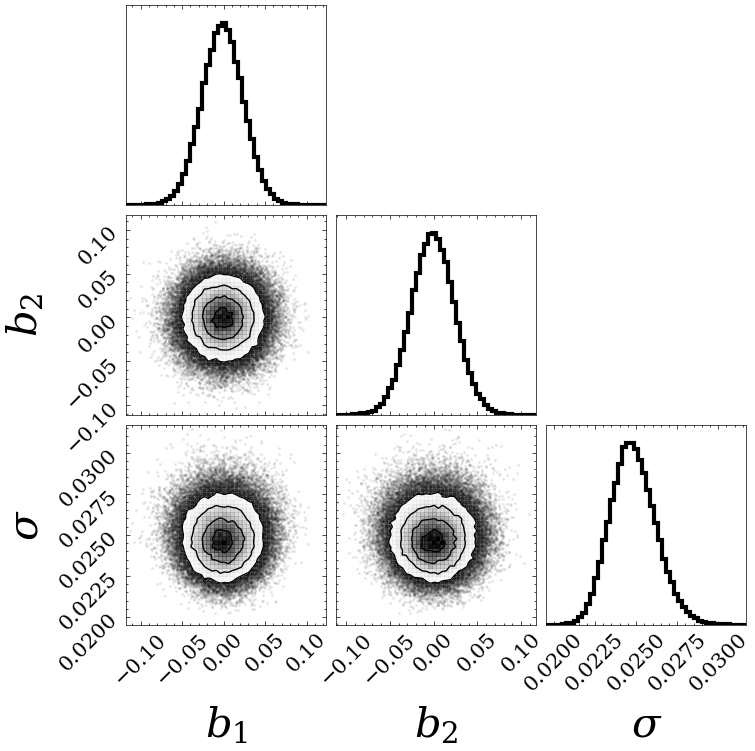

In [267]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [268]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights = []
for beta in samples:
    model_weights.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights= np.array(model_weights)

In [269]:
filtered_model_predictions_mass_50 = filtered_models_output_mass_50.iloc[:,3:-1].values

In [270]:
# We need to find a way to quantify the uncertainty for the radius. In this case, what we are going to do is to use the RMSE
# calculated from the training data sets when we use the mean value of the parameters we samples to make our predictions

In [271]:
model_weights.shape
model_weights_mean = np.mean(model_weights, axis = 0)

mass_predictions_mean = np.dot(model_weights_mean, model_predictions_mass_train.T)
sigma_naive_mass = np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-mass_predictions_mean)/np.sqrt(len(mass_predictions_mean))
sigma_naive_mass

2.004587349536056

In [272]:
rndm_m_mass = []
for i in range(len(model_weights)):
    if centering_data:
        yvals_rand_mass= filtered_model_predictions_mass_50.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * sigma_naive_mass**2 ) )))  
        
lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

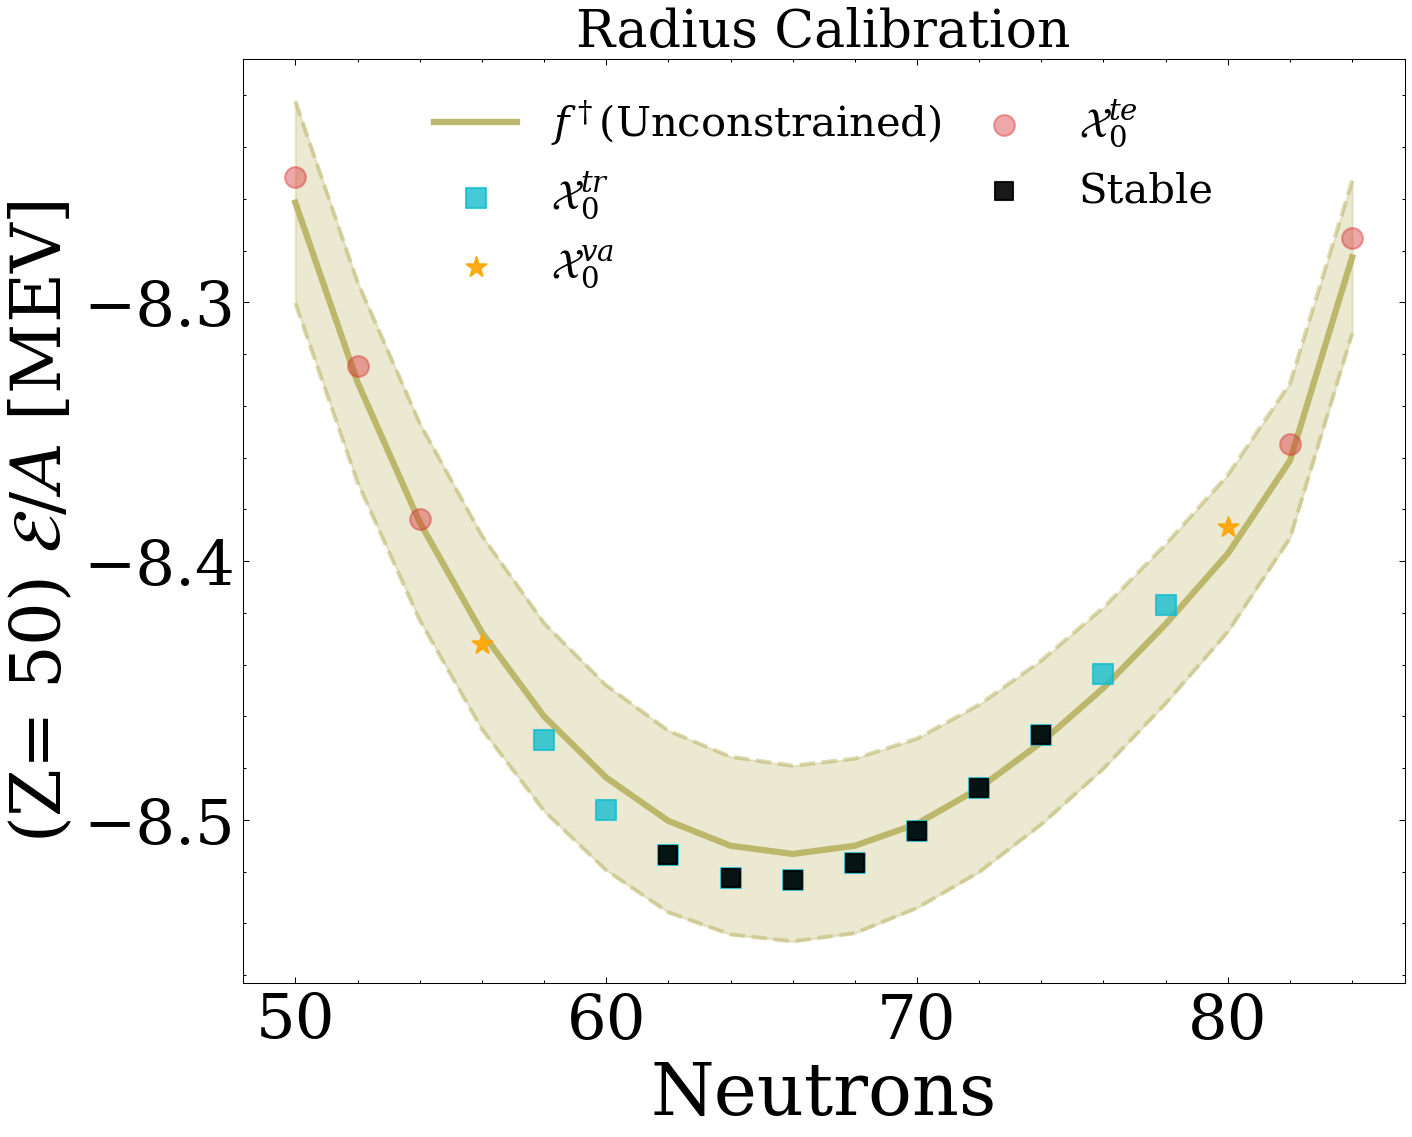

In [173]:
supermodel_predictions_mass_range = [lower_mass, median_mass, upper_mass]
# title = 'Radius Calibration'
# savefig_50_mass = 'Plots/Heterogeneous Real Scaled Analysis/Binding Energies predictions/Unconstrained BE forecasts for Z = 50 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_mass_range, filtered_models_output_mass_list_50, 50, 'MEV', 'E', 'Unconstrained', title, savefig_50_mass)

In [129]:
filtered_model_predictions_radius_20 = filtered_models_output_radius_20.iloc[:,3:-1].values

In [130]:
lower_radius, median_radius, upper_radius = rndm_m_radius_calculator(model_weights, filtered_model_predictions_radius_20, samples)

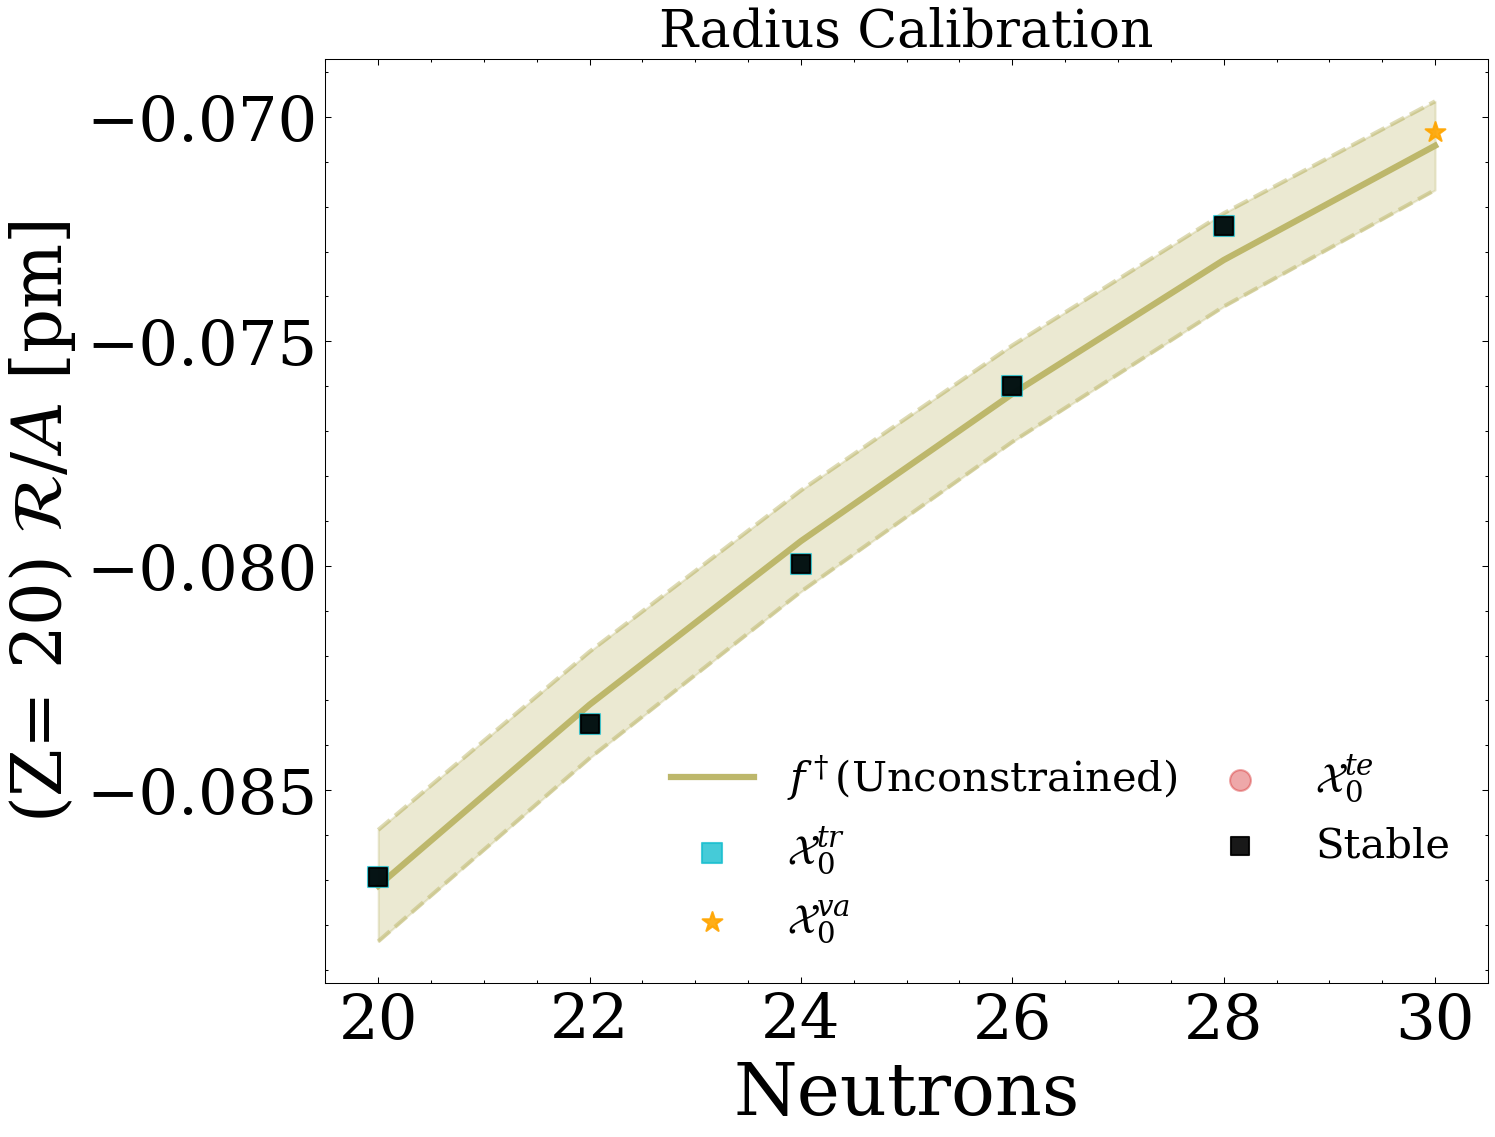

In [175]:
supermodel_predictions_radius_range = [lower_radius, median_radius, upper_radius]
# title = 'Radius Calibration'
# savefig_20_radius = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Unconstrained CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range, filtered_models_output_radius_list_20, 20, 'pm', 'R', 'Unconstrained', title, savefig_20_radius)

### Simplex

In [132]:
nu0_chosen=1
sigma20_chosen=0.05
bias0=np.full(len(model_predictions_mass_train.T),1/len(model_predictions_mass_train.T))
#This term will be added to the \omegas when obtaining them from the \betas to account for centering the data

In [133]:
def gibbs_sampler_simplex(y, X, iterations,prior_info,burn=10000,stepsize=0.001):
    # if centering_data == False:
    #     print("Only available for centering data")
    #     return 
    #Make sure that "y" has the correct structure. If data is being centered, it should have the mean already substracted
#     b_mean_prior, b_mean_cov, nu0, sigma20  =  prior_info
    
    nu0, sigma20  =  prior_info   #Since our prior is only in \sigma, we are letting the \betas be free beyond the simplex
    
    #From A_First_Course_in_Bayesian_Statistical_Methods (page ~ 159), nu0 represent the effective prior samples and sigma2_0 represents the expected prior variance
    
    cov_matrix_step=np.diag(S_hat**2*stepsize**2)
    
    n = len(y)
    
    #Initializing the starting point at the average of all the models
    b_current = np.full(len(X),0)

    
    
    supermodel_current=X.T.dot(b_current)
    

    residuals_current = y - supermodel_current 

    
  
    log_likelihood_current= -np.sum(residuals_current**2)
    
    
    sigma2 = -log_likelihood_current/ len(residuals_current) 

    
    
    samples = []
    acceptance=0
    
    for i in range(burn):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

        
            #Comment this line and uncomment the next if you want to check MCMC without the simplex  
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        
        else:
            
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed

        shape_post = (nu0 + n)/2.
        
        
#         scale_post = (nu0*sigma20 - log_likelihood_current/len(residuals_current))/2.0
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
#         samples.append(np.append(b_current,np.sqrt(sigma2)))
        
        
  

    for i in range(iterations):
        # Sample from the conditional posterior of bs given sigma2 and data       
        b_proposed =  np.random.multivariate_normal(b_current, cov_matrix_step)
        
        omegas_proposed=np.dot(b_proposed,Vt_hat) + bias0

    #Comment this line and uncomment the next if you want to check MCMC without the simplex    
        if  np.any(omegas_proposed < 0):
            pass
        
#         if 1>2:
#             pass
        else:
            supermodel_proposed=X.T.dot(b_proposed)
    
            residuals_proposed = y - supermodel_proposed 

            log_likelihood_proposed= -np.sum(residuals_proposed**2)
            
#           Calculate the acceptance probability
            acceptance_prob = min(1, np.exp(   (+log_likelihood_proposed - log_likelihood_current)/sigma2   ))

            # Accept or reject the proposal
            if np.random.uniform() < acceptance_prob:
                b_current = np.copy(b_proposed)
                log_likelihood_current=log_likelihood_proposed
                acceptance=acceptance+1

        shape_post = (nu0 + n)/2.
        
        scale_post = (nu0*sigma20 - log_likelihood_current)/2.0

        sigma2 = 1 / np.random.default_rng().gamma(shape_post, 1/scale_post)
        
        
        samples.append(np.append(b_current,np.sqrt(sigma2)))        
        
        
        
        
        
        
    

    print("percentage accepted:", round(acceptance/iterations*100))
    return np.array(samples)

In [134]:
%%time
samples_simplex=gibbs_sampler_simplex(y_radius, X.T, 500000,[nu0_chosen, sigma20_chosen],burn=300000,stepsize=0.1)

percentage accepted: 26
CPU times: total: 3min 3s
Wall time: 3min 4s


In [135]:
label_global = [f'$b_{i}$' for i in range(1, components_kept+1)]
label_global.append(f'$\sigma$')

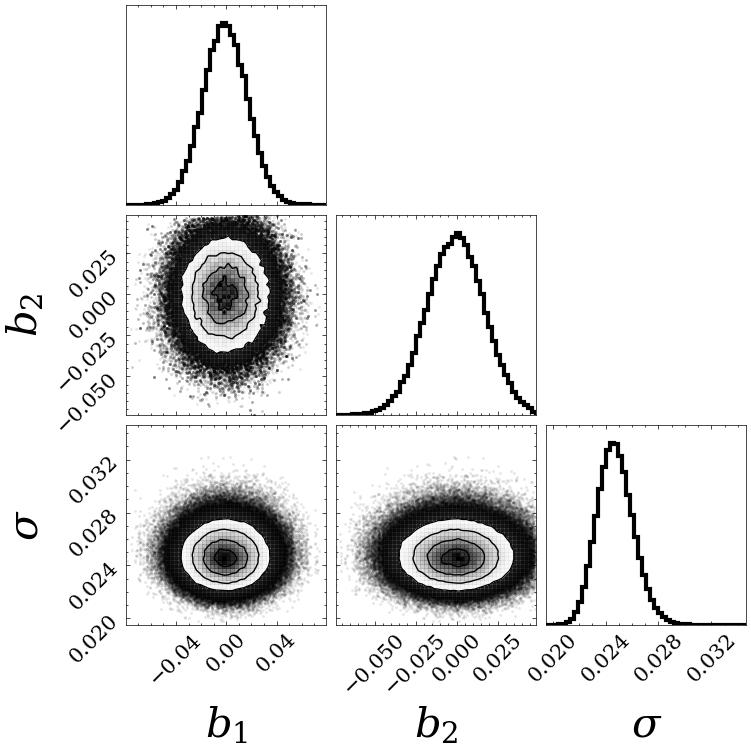

In [136]:
plt.rc("xtick", labelsize=15)
plt.rc("ytick", labelsize=15)

figure = corner.corner(samples_simplex,bins=50, dpi=300, hist_kwargs={"linewidth": 3},
                       labels=label_global, 
                    #    truths=np.append(beta,np.sqrt(sigma_squared)),
                    #    truth_color="r",
                       label_kwargs={"fontsize": 30},labelpad=0.1)
plt.show()

In [137]:
# This code will help us to calculate the weight of the individual models from the weight of the principal components
model_weights_simplex = []
for beta in samples_simplex:
    model_weights_simplex.append(np.dot(beta[:-1], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
model_weights_simplex = np.array(model_weights_simplex)

In [138]:
model_weights_simplex.shape
model_weights_mean_simplex = np.mean(model_weights_simplex, axis = 0)

mass_predictions_mean_simplex = np.dot(model_weights_mean_simplex, model_predictions_mass_train.T)
sigma_naive_mass_simplex = np.linalg.norm(np.array(models_output_mass_train["truth"].tolist())-mass_predictions_mean_simplex)/np.sqrt(len(mass_predictions_mean_simplex))
sigma_naive_mass_simplex

2.004338737710672

In [139]:
rndm_m_mass_simplex = []
for i in range(len(model_weights_simplex)):
    if centering_data:
        yvals_rand_mass= filtered_model_predictions_mass_50.dot(model_weights_simplex[i].T)
    # else:
    #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])

    rndm_m_mass_simplex.append(yvals_rand_mass +
                   np.random.multivariate_normal(np.full(
                       len(yvals_rand_mass)
                       ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * sigma_naive_mass_simplex**2 ) )))  
lower_mass_simplex = np.percentile(rndm_m_mass_simplex, 2.5, axis = 0)
median_mass_simplex = np.percentile(rndm_m_mass_simplex, 50, axis = 0)
upper_mass_simplex = np.percentile(rndm_m_mass_simplex, 97.5, axis = 0)

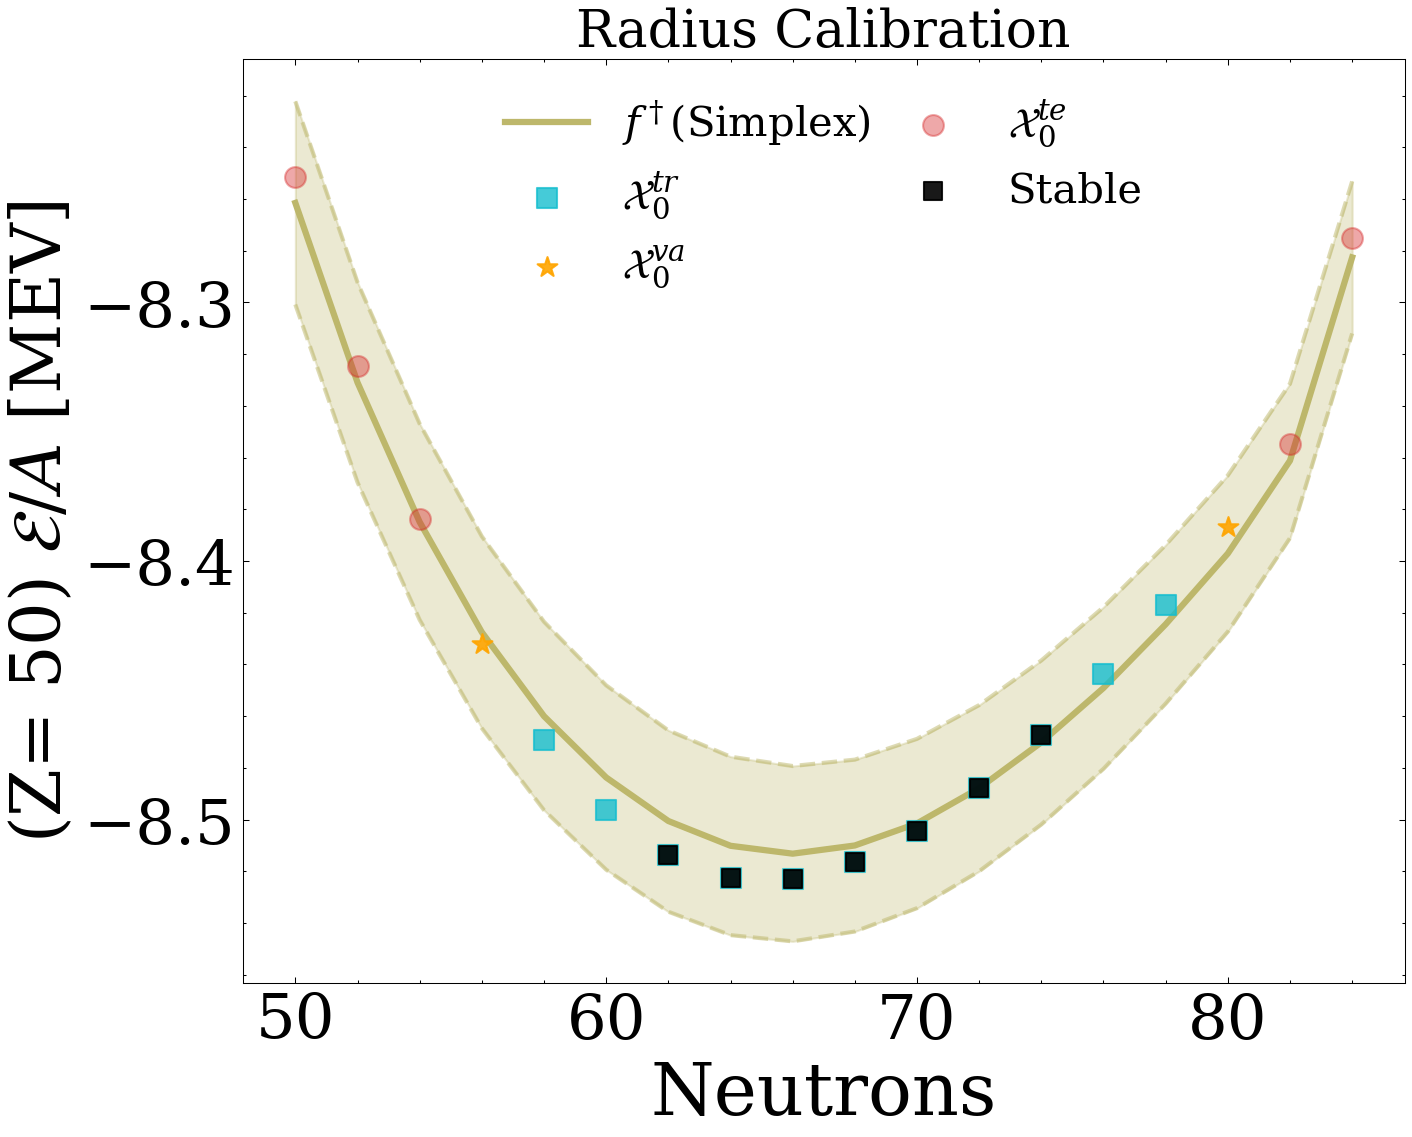

In [177]:
supermodel_predictions_mass_range_simplex = [lower_mass_simplex, median_mass_simplex, upper_mass_simplex]
# title = 'Radius Calibration'
# savefig_50_mass_simplex = 'Plots/Heterogeneous Real Scaled Analysis/Binding Energies predictions/Simplex BE forecasts for Z = 50 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_mass_range_simplex, filtered_models_output_mass_list_50, 50, 'MEV', 'E', 'Simplex', title, savefig_50_mass_simplex)

In [141]:
lower_radius_simplex, median_radius_simplex, upper_radius_simplex = rndm_m_radius_calculator(model_weights_simplex, filtered_model_predictions_radius_20, samples_simplex)

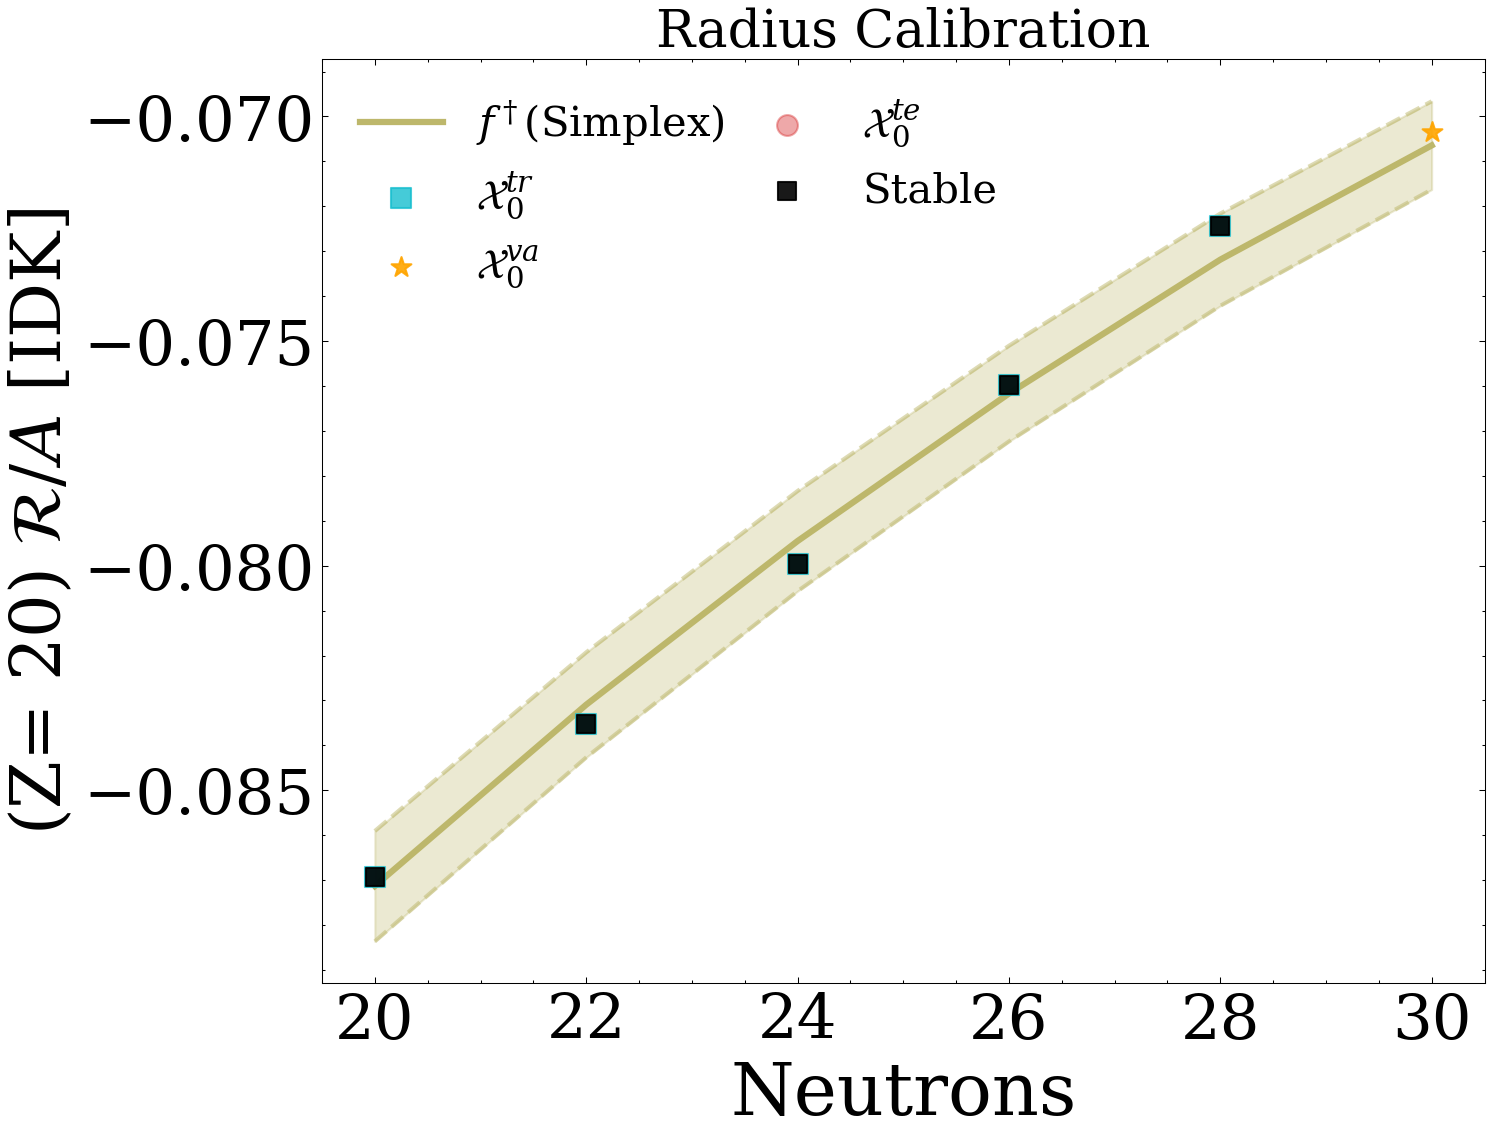

In [178]:
supermodel_predictions_radius_range_simplex = [lower_radius_simplex, median_radius_simplex, upper_radius_simplex]
# title = 'Radius Calibration'
# savefig_20_radius_simplex = 'Plots/Heterogeneous Real Scaled Analysis/Radius predictions/Simplex CR forecasts for Z = 20 - Radius Analysis - 2PCs.png'
plot_filtered_supermodel(supermodel_predictions_radius_range_simplex, filtered_models_output_radius_list_20, 20, 'IDK', 'R', 'Simplex', title, savefig_20_radius_simplex)

### The next step is to compare the weights of the models when calibrating using different properties

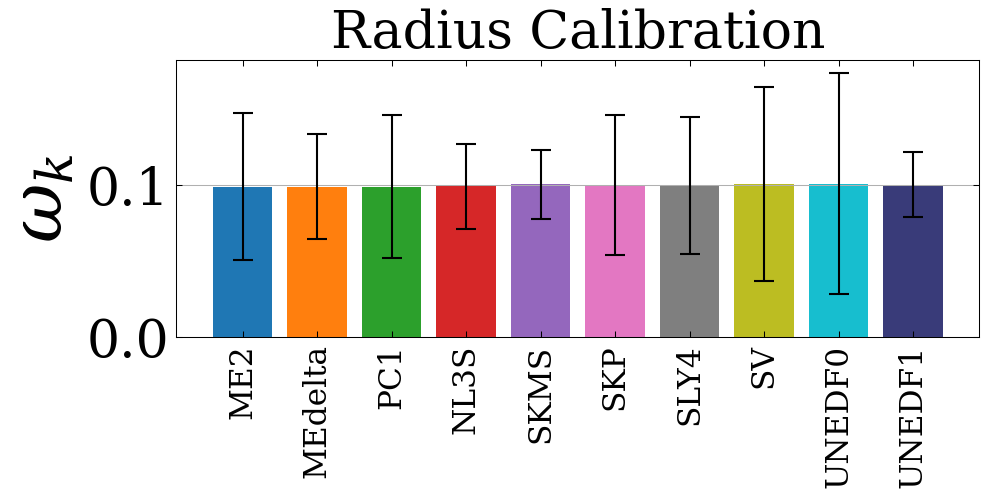

In [180]:
plt.rc("xtick", labelsize=20)
plt.rc("ytick", labelsize=20)
# labels=list(models_output.keys())
plt.figure(figsize=(7, 3.5),dpi=150)
# y_max=0.6


i=0
for model in key_list:
        
        # ax.plot(filtered_models_output["N"], filtered_models_output[key_list[model_index]], 
        #         label = n_Labels[class_index], color=colors[class_index],alpha = alpha_models,linewidth=5)
        # plt.bar(model , np.mean(samples_naive_space_sigma.T[i]), color=colors[i])
        plt.bar(model , 
                np.mean(model_weights_simplex, axis  = 0)[i],yerr=2*np.std(model_weights_simplex.T[i]),
                color=colors[i],capsize=5)
        i=i+1




# plt.xlabel('Models',fontsize=15)
# plt.title("c)",fontsize=25)
plt.minorticks_off()
plt.ylabel('$\omega_k$',fontsize=35)
# plt.ylim(0,0.45)
plt.xticks(fontsize=15,rotation='vertical')
plt.yticks(fontsize=25)
plt.grid(axis='y')
plt.title('Radius Calibration', fontsize = 25)
plt.tight_layout()
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/Model weights/Simplex models weights - Radius Analysis - 2PCs.png')
plt.show()


## The next step is to compare the performance of the coverage graph in both radius and mass with respect to our mass and radius analysis

In [144]:
rndm_m_full_mass_train_simplex = rndm_m_mass_calculator_coverage(sigma_naive_mass_simplex, model_predictions_mass_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:35<00:00, 140.44it/s]


In [145]:
rndm_m_full_mass_train_simplex.shape

(5000, 300)

In [146]:
rndm_m_full_mass_validation_simplex = rndm_m_mass_calculator_coverage(sigma_naive_mass_simplex, model_predictions_mass_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:01<00:00, 2601.82it/s]


In [147]:
rndm_m_full_mass_test_simplex = rndm_m_mass_calculator_coverage(sigma_naive_mass_simplex, model_predictions_mass_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:26<00:00, 191.55it/s]


In [148]:
rndm_m_full_radius_train_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_train, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:09<00:00, 529.34it/s]


In [149]:
rndm_m_full_radius_validation_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_validation, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:01<00:00, 2643.47it/s]


In [150]:
rndm_m_full_radius_test_simplex = rndm_m_radius_calculator_coverage(samples_simplex, model_predictions_radius_test, 5000, Vt_hat)

100%|██████████| 5000/5000 [00:04<00:00, 1110.16it/s]


In [151]:
coverage_mass_train_simplex = coverage_calculation(rndm_m_full_mass_train_simplex, models_output_mass_train)

In [152]:
coverage_mass_validation_simplex = coverage_calculation(rndm_m_full_mass_validation_simplex, models_output_mass_validation)

In [153]:
coverage_mass_test_simplex = coverage_calculation(rndm_m_full_mass_test_simplex, models_output_mass_test)

In [154]:
percentiles = np.arange(0,101,5)

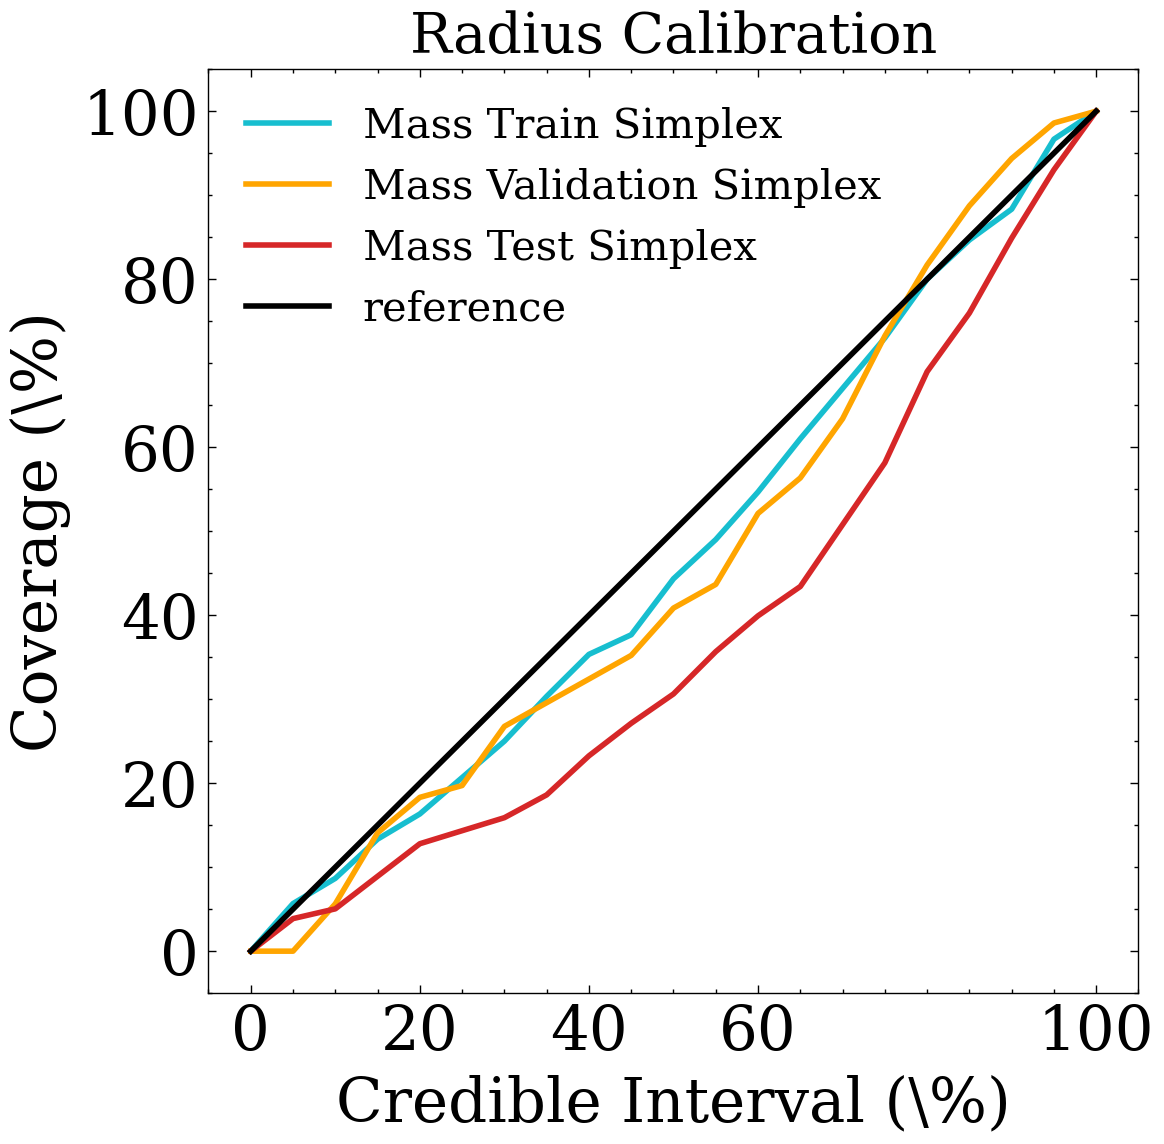

In [181]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_mass_train_simplex, label='Mass Train Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_mass_validation_simplex, label='Mass Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_mass_test_simplex, label='Mass Test Simplex',color=color_test,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Radius Calibration', fontsize = 20)
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/ECP Graphs/Simplex Mass ECP - Radius Analysis - 2PCs.png')
plt.show()

In [156]:
coverage_radius_train_simplex = coverage_calculation(rndm_m_full_radius_train_simplex, models_output_radius_train)

In [157]:
coverage_radius_validation_simplex = coverage_calculation(rndm_m_full_radius_validation_simplex, models_output_radius_validation)

In [158]:
coverage_radius_test_simplex = coverage_calculation(rndm_m_full_radius_test_simplex, models_output_radius_test)

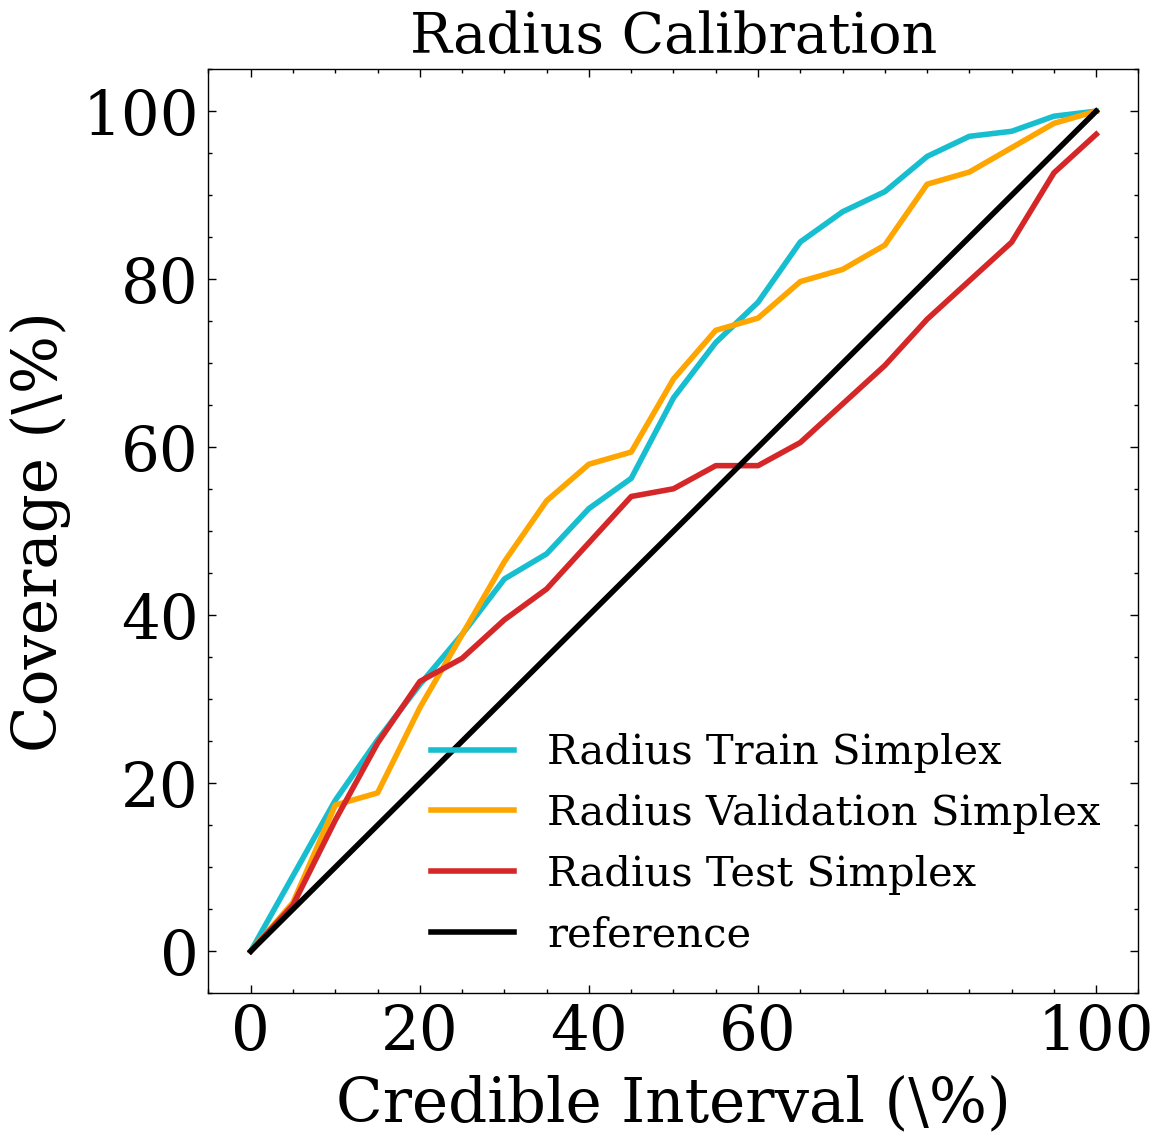

In [182]:
plt.rc("xtick", labelsize=22)
plt.rc("ytick", labelsize=22)
# Plotting the results
plt.figure(figsize=(6, 6),dpi=200)

width_line=2

plt.plot(percentiles, coverage_radius_train_simplex, label='Radius Train Simplex',color=color_train,linewidth=width_line)
plt.plot(percentiles, coverage_radius_validation_simplex, label='Radius Validation Simplex',color=color_validation,linewidth=width_line)
plt.plot(percentiles, coverage_radius_test_simplex, label='Radius Test Simplex',color=color_test,linewidth=width_line)


# plt.plot(percentiles, coverage_train_simplex,linestyle='dashed', label='Training',color=color_trainig,linewidth=width_line)
# plt.plot(percentiles, coverage_validation_simplex, linestyle='dashed',label='Validation',color=color_validation,linewidth=width_line)
# plt.plot(percentiles, coverage_test_simplex,linestyle='dashed', label='Test',color=color_testing,linewidth=width_line)



plt.plot(percentiles, percentiles,label='reference',color='k',linewidth=width_line)
plt.xlabel('Credible Interval (\%)',fontsize=22)
plt.ylabel('Coverage (\%)',fontsize=22)

plt.xticks(ticks=[0, 20,40,60,100])

plt.title('Radius Calibration', fontsize = 20)
# plt.grid(True)
plt.legend(fontsize=15)
plt.savefig('Plots/Heterogeneous Real Scaled Analysis/ECP Graphs/Simplex Radius ECP - Radius Analysis - 2PCs.png')
plt.show()